<a href="https://colab.research.google.com/github/NataKrj/Automated-Risk-Scoring-System/blob/main/Rules_based_synthetic_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 data_loade - Countries and Offshore Leaks-entities

In [ ]:
# data_loader.py

import pandas as pd
import random

def load_country_risk_data(file_path='COUNTRY ASSESSMENT Short.xlsx'):
    """Load country risk data from Excel file and categorize countries"""
    # Load the Excel file
    df = pd.read_excel(file_path)

    # Create a dictionary of countries with their risk scores
    country_risk_data = {}
    if 'Country' in df.columns and 'Consolidated risk score' in df.columns:
        for _, row in df.iterrows():
            country = row['Country']
            risk_score = row['Consolidated risk score']
            if pd.notna(country) and pd.notna(risk_score):
                country_risk_data[country] = float(risk_score)

    # Group countries by risk level
    prohibited_countries = []
    very_high_risk_countries = []
    high_risk_countries = []
    medium_risk_countries = []
    low_risk_countries = []

    for country, score in country_risk_data.items():
        if score >= 0.99:
            prohibited_countries.append(country)
        elif score >= 0.9:
            very_high_risk_countries.append(country)
        elif score >= 0.7:
            high_risk_countries.append(country)
        elif score >= 0.3:
            medium_risk_countries.append(country)
        else:
            low_risk_countries.append(country)

    return {
        'prohibited_countries': prohibited_countries,
        'very_high_risk_countries': very_high_risk_countries,
        'high_risk_countries': high_risk_countries,
        'medium_risk_countries': medium_risk_countries,
        'low_risk_countries': low_risk_countries
    }

def load_offshore_companies(file_path='Offshore Leaks-entities.csv'):
    """Load offshore companies from CSV file"""
    try:
        df_shell_companies = pd.read_csv(file_path, usecols=['original_name'], low_memory=False)
        known_shell_companies = set(df_shell_companies['original_name'].dropna().unique().tolist())
        print(f"Loaded {len(known_shell_companies)} companies from Offshore Leaks database")
        return known_shell_companies
    except FileNotFoundError:
        print("Offshore Leaks file not found. Proceeding without offshore company data.")
        return set()

def is_offshore_company(company_name, known_shell_companies):
    """Check if a company name matches or is similar to known offshore companies"""
    return company_name in known_shell_companies

# 2 The company name generation

In [ ]:
# utils.py

import random
from datetime import datetime, timedelta
import math

# Business name components
business_types = ['Holdings', 'Investments', 'Trading', 'Capital', 'Ventures', 'Partners', 'Group', 'Solutions', 'International', 'Global']
industries = ['Tech', 'Finance', 'Trade', 'Consulting', 'Services', 'Logistics', 'Maritime', 'Energy', 'Resources', 'Development']
locations = ['Asia', 'Pacific', 'Atlantic', 'European', 'Eastern', 'Western', 'Northern', 'Southern', 'Continental', 'International']
suffixes = ['Ltd', 'LLC', 'Inc', 'Corp', 'Limited', 'S.A.', 'GmbH', 'Pte Ltd', 'B.V.', 'AG']
prefixes = ['Alpha', 'Beta', 'Delta', 'Omega', 'Prime', 'Elite', 'Summit', 'Apex', 'Crown', 'Royal']

def generate_company_name(known_shell_companies=None):
    """Generate a company name, occasionally using a known offshore company name"""
    if known_shell_companies and random.random() < 0.1:
        return random.choice(list(known_shell_companies))

    patterns = [
        lambda: f"{random.choice(prefixes)} {random.choice(industries)} {random.choice(suffixes)}",
        lambda: f"{random.choice(locations)} {random.choice(business_types)} {random.choice(suffixes)}",
        lambda: f"{random.choice(['New', 'First', 'Premier'])} {random.choice(locations)} {random.choice(business_types)}",
        lambda: f"{random.choice(prefixes)} {random.choice(business_types)} {random.choice(suffixes)}",
        lambda: f"{random.choice(['Global', 'Universal', 'World'])} {random.choice(industries)} {random.choice(suffixes)}"
    ]
    return random.choice(patterns)()

company_types = ['Technology', 'Consulting', 'Financial', 'Manufacturing', 'Healthcare', 'Retail',
                       'Hospitality', 'Energy', 'Transportation', 'Telecommunications', 'Construction']

def generate_company_lists(known_shell_companies=None):
    """Generate company lists with types for transaction scenarios"""
    num_shell_companies = 50
    num_associates = 100
    num_new_companies = 30

    def generate_typed_company():
        company_type = random.choice(company_types)  # Ensure a type is always assigned
        return {
            'name': generate_company_name(known_shell_companies),
            'type': company_type
        }

    initial_customers = [generate_typed_company() for _ in range(num_shell_companies)]
    associates = [generate_typed_company() for _ in range(num_associates)]
    newly_incorporated = [generate_typed_company() for _ in range(num_new_companies)]

    # Create a mapping of company names to their types
    client_types = {company['name']: company['type'] for company in initial_customers + associates + newly_incorporated}

    # Debugging output
    print("Client Types:", client_types)

    return {
        'initial_customers': initial_customers,
        'associates': associates,
        'newly_incorporated': newly_incorporated,
        'known_shell_companies': known_shell_companies or set(),
        'client_types': client_types  # Include client types in the return
    }

# 3 normal transactions

In [ ]:
#3 normal transactions

import random
import math
from datetime import datetime, timedelta
from collections import defaultdict


# Define date range constants
DEFAULT_START_DATE = datetime(2023, 1, 1)
DEFAULT_END_DATE = datetime(2023, 12, 31)

# Transaction parameters
DEFAULT_CURRENCIES = ['USD', 'EUR', 'GBP', 'JPY', 'CHF']

# Company profiles with integrated descriptions
company_profiles = {
    'Technology': {
        'transaction_types': [
            'Software License Payment', 'IT Infrastructure Services',
            'Cloud Service Subscription', 'Technical Support Services',
            'Development Services'
        ],
        'amount_range': (5000, 50000),
        'descriptions': [
            'Software license renewal - License No: SFT-{year}-{num}, Invoice: LIC-{inv_num}',
            'Cloud service subscription - Sub ID: CLD-{year}-{num}, Invoice: SUB-{inv_num}',
            'IT Infrastructure upgrade - Project: INF-{year}-{num}, Invoice: TECH-{inv_num}',
            'Development services - Sprint: DEV-{year}-{num}, Invoice: CODE-{inv_num}',
            'Technical support contract - Support ID: SUP-{year}-{num}, Invoice: HELP-{inv_num}',
            'Cybersecurity services - Security ID: SEC-{year}-{num}, Invoice: CYB-{inv_num}',
            'Data center services - DC ID: DCT-{year}-{num}, Invoice: DATA-{inv_num}',
            'Enterprise resource planning (ERP) setup - ERP ID: ERP-{year}-{num}, Invoice: SYS-{inv_num}',
            'Custom database deployment - DB ID: DB-{year}-{num}, Invoice: BASE-{inv_num}',
            'Hosting fees for SaaS platform - Host ID: HST-{year}-{num}, Invoice: HOST-{inv_num}',
            'UI/UX redesign service - UX ID: UX-{year}-{num}, Invoice: DESIGN-{inv_num}',
            'API integration service - API ID: API-{year}-{num}, Invoice: INT-{inv_num}',
            'Mobile app maintenance - App ID: MOB-{year}-{num}, Invoice: APP-{inv_num}',
            'Legacy system migration - Migration ID: LEG-{year}-{num}, Invoice: MIG-{inv_num}',
            'Blockchain pilot project - Contract: BLK-{year}-{num}, Invoice: CHAIN-{inv_num}',
            'DevOps pipeline setup - CI/CD Ref: DVP-{year}-{num}, Invoice: PIPE-{inv_num}',
            'License Renewal: Invoice {inv_num} / License No: SFT-{year}-{num}',
            'Cloud sub ID: CLD-{num}-{year}, BillRef SUB-{inv_num}',
            'Infra upgrade - Tech invoice TECH-{inv_num}, Project INF-{num}-{year}',
            'Dev services / Sprint: DEV-{num}-{year}, codeRef CODE-{inv_num}',
            'Support Contract #HELP-{inv_num}, ID SUP-{year}-{num}',
            'Cybersec patch: SEC-{year}-{num}, docNo CYB-{inv_num}',
            'Data Center ops => dataRef DATA-{inv_num}, DC ID: DCT-{num}-{year}',
            'ERP setup? SYS-{inv_num}, ID ERP-{year}-{num}',
            'API integr => INT-{inv_num}, token: API-{num}-{year}',
            'Legacy migration partial doc MIG-{inv_num}, legacy ID: LEG-{year}-{num}',
            'Continuous integration tool license - License Key: CIT-{year}-{num}, Invoice: LIC-{inv_num}',
            'Cloud backup subscription - Sub ID: CBU-{year}-{num}, BillRef BACK-{inv_num}',
            'Network security upgrade - Project: NET-{year}-{num}, Invoice: SAFE-{inv_num}',
            'DevOps consulting retainer - Sprint: DVC-{year}-{num}, Invoice: DEVOPS-{inv_num}',
            'Advanced support contract - Support ID: ASUP-{year}-{num}, Invoice: HELPDESK-{inv_num}',
            'Anti-virus services - Security ID: AV-{year}-{num}, Invoice: CYBSEC-{inv_num}',
            'Server colocation fees - DC ID: COLO-{year}-{num}, Invoice: DATACENTER-{inv_num}',
            'ERP upgrade module - ERP ID: ERPUP-{year}-{num}, Invoice: SYSUP-{inv_num}',
            'Database optimization - DB ID: ODB-{year}-{num}, Invoice: DBTUNE-{inv_num}',
            'Hosting SLA fees - Host ID: SLA-{year}-{num}, Invoice: HOSTSLA-{inv_num}',
            'Mobile app feature dev - App ID: MOBFEAT-{year}-{num}, Invoice: APPDEV-{inv_num}',
            'UI/UX prototyping service - UX ID: PROTO-{year}-{num}, Invoice: DESIGNUI-{inv_num}',
            'API re-integration service - API ID: REAPI-{year}-{num}, Invoice: INTNEW-{inv_num}',
            'Microservice container maintenance - Container ID: MSC-{year}-{num}, Invoice: DOCKER-{inv_num}',
            'Smart contract pilot project - Contract: SMRT-{year}-{num}, Invoice: BLOCK-{inv_num}',
            'DevOps pipeline refactor - Pipeline Ref: DVPR-{year}-{num}, Invoice: PIPELINE-{inv_num}',
            'Extended license contract: Invoice {inv_num} / License No: SFTX-{year}-{num}',
            'Additional cloud sub ID: CLD2-{num}-{year}, BillRef SUB2-{inv_num}',
            'Infrastructure modernization - Tech invoice TECHMOD-{inv_num}, Project INFMOD-{num}-{year}',
            'Consulting services / Sprint: CNSL-{num}-{year}, codeRef CODECONS-{inv_num}',
            'Enterprise support contract #HELPX-{inv_num}, ID SUPX-{year}-{num}',
            'Cybersecurity incident response: SECINC-{year}-{num}, docNo CYBINC-{inv_num}',
            'Data center migration => dataRef DATAMIG-{inv_num}, DC ID: DCTM-{num}-{year}',
            'Advanced ERP config? SYSADV-{inv_num}, ID ERPADV-{year}-{num}',
            'API extension => INTX-{inv_num}, token: APIX-{num}-{year}',
            'Legacy app transformation MIGUP-{inv_num}, legacy ID: LEGUP-{year}-{num}',
            'Software license patch - License No: PCH-{year}-{num}, Invoice: LICPATCH-{inv_num}',
            'Cloud analytics subscription - Sub ID: CLAN-{year}-{num}, Invoice: ANSUB-{inv_num}',
            'IT Infrastructure scale-out - Project: INFSC-{year}-{num}, Invoice: TECHSC-{inv_num}',
            'Custom plugin development - Sprint: PLG-{year}-{num}, Invoice: PLGDEV-{inv_num}',
            'Technical support desk - Support ID: TSD-{year}-{num}, Invoice: HELPD-{inv_num}',
            'Endpoint protection service - Security ID: EPSEC-{year}-{num}, Invoice: CYBEP-{inv_num}',
            'Database replication setup - DB ID: REPL-{year}-{num}, Invoice: DBREP-{inv_num}',
            'SaaS platform license - Host ID: SAAS-{year}-{num}, Invoice: HSTSAAS-{inv_num}'
        ]
    },
    'Consulting': {
        'transaction_types': [
            'Advisory Services', 'Business Strategy Consulting',
            'Management Consulting', 'Professional Services',
            'Project Consultation'
        ],
        'amount_range': (10000, 75000),
        'descriptions': [
            'Management consulting - Project: MGT-{year}-{num}, Invoice: CONS-{inv_num}',
            'Strategy advisory services - Matter No: STR-{year}-{num}, Invoice: ADV-{inv_num}',
            'Business process optimization - Project: BPO-{year}-{num}, Invoice: OPT-{inv_num}',
            'Market research services - Research ID: MKT-{year}-{num}, Invoice: RES-{inv_num}',
            'Professional training - Course: TRN-{year}-{num}, Invoice: EDU-{inv_num}',
            'Compliance advisory - Matter No: CMP-{year}-{num}, Invoice: REG-{inv_num}',
            'Organizational restructuring - Project: ORG-{year}-{num}, Invoice: STRC-{inv_num}',
            'Executive leadership coaching - Program: LDR-{year}-{num}, Invoice: EXE-{inv_num}',
            'Corporate governance review - Matter No: GOV-{year}-{num}, Invoice: CGR-{inv_num}',
            'Digital transformation roadmap - Project: DIG-{year}-{num}, Invoice: TRANS-{inv_num}',
            'Operational risk assessment - Ref: RSK-{year}-{num}, Invoice: OPS-{inv_num}',
            'Mgmt consult. - MGT-{num}-{year}, docRef CONS-{inv_num}',
            'Strategy adv? Matter STR-{year}-{num}, invoice ADV-{inv_num}',
            'Biz process optimize => BPO-{num}-{year}, Bill: OPT-{inv_num}',
            'Market research - MKT-{num}-{year}, docNo RES-{inv_num}',
            'Professional training - EDU-{inv_num}, course TRN-{year}-{num}',
            'Compliance advice: REG-{inv_num}, matter CMP-{year}-{num}',
            'Org restructure => STRC-{inv_num}, Project ORG-{num}-{year}',
            'Exec coaching => EXE-{inv_num}, Program LDR-{year}-{num}',
            'Digital transform: TRANS-{inv_num}, ID DIG-{year}-{num}',
            'Operational risk check => OPS-{inv_num}, RSK-{year}-{num}',
            'Intl expansion feasibility => EXPN-{inv_num}, code INTL-{year}-{num}',
            'Digital strategy - DIG-{year}-{num}, Inv: STR-{inv_num}',
            'IT advisory - ITAD-{year}-{num}, Inv: TRANS-{inv_num}',
            'Human capital review - HCR-{year}-{num}, Inv: HC-{inv_num}',
            'M&A advisory - MAA-{year}-{num}, Inv: MERGE-{inv_num}',
            'Change management - CM-{year}-{num}, Inv: CHANGE-{inv_num}',
            'Risk strategy - RS-{year}-{num}, Inv: MIT-{inv_num}',
            'Financial restructuring - FR-{year}-{num}, Inv: FINR-{inv_num}',
            'Customer experience - CX-{year}-{num}, Inv: CUST-{inv_num}',
            'Supply chain review - SCR-{year}-{num}, Inv: SUPC-{inv_num}',
            'Org effectiveness - OE-{year}-{num}, Inv: EFF-{inv_num}',
            'IT infrastructure - ITINF-{year}-{num}, Inv: INFRA-{inv_num}',
            'Sustainability plan - SUS-{year}-{num}, Inv: GREEN-{inv_num}',
            'Continuity planning - CP-{year}-{num}, Inv: CONT-{inv_num}',
            'Market entry - ME-{year}-{num}, Inv: ENTRY-{inv_num}',
            'Cyber risk - CYR-{year}-{num}, Inv: SEC-{inv_num}',
            'Innovation review - INNO-{year}-{num}, Inv: IDEAS-{inv_num}',
            'Cost reduction - CR-{year}-{num}, Inv: SAVE-{inv_num}',
            'Operational excellence - OPEX-{year}-{num}, Inv: EXCEL-{inv_num}',
            'Strategy execution - SE-{year}-{num}, Inv: EXEC-{inv_num}',
            'Rebranding - RB-{year}-{num}, Inv: BRAND-{inv_num}',
            'Digital marketing - DM-{year}-{num}, Inv: ONLINE-{inv_num}',
            'Employee engagement - EE-{year}-{num}, Inv: ENG-{inv_num}',
            'Process automation - PA-{year}-{num}, Inv: AUTO-{inv_num}',
            'Data analytics - DA-{year}-{num}, Inv: ANALY-{inv_num}',
            'IT risk - ITR-{year}-{num}, Inv: RISK-{inv_num}',
            'Global expansion - GE-{year}-{num}, Inv: GLOBAL-{inv_num}',
            'Outsourcing - OUT-{year}-{num}, Inv: SOURC-{inv_num}',
            'Exec coaching - EC-{year}-{num}, Inv: COACH-{inv_num}',
            'Regulatory advisory - REG-{year}-{num}, Inv: LAW-{inv_num}',
            'Customer retention - CRR-{year}-{num}, Inv: RET-{inv_num}',
            'Competitive analysis - CA-{year}-{num}, Inv: ANAL-{inv_num}',
            'Innovation lab setup - ILS-{year}-{num}, Inv: LAB-{inv_num}',
            'Merger integration - MI-{year}-{num}, Inv: INT-{inv_num}',
            'Sourcing strategy - SS-{year}-{num}, Inv: SRC-{inv_num}',
            'Business model review - BMR-{year}-{num}, Inv: MODE-{inv_num}',
            'Digital risk - DR-{year}-{num}, Inv: RISKD-{inv_num}',
            'Cloud advisory - CLA-{year}-{num}, Inv: CLOAD-{inv_num}',
            'Lean optimization - LO-{year}-{num}, Inv: OPT-{inv_num}'
        ]
    },
    'Financial': {
        'transaction_types': [
            'Investment Services', 'Financial Advisory',
            'Asset Management', 'Trading Operations',
            'Portfolio Management'
        ],
        'amount_range': (20000, 150000),
        'descriptions': [
            'Investment advisory services - Portfolio: INV-{year}-{num}, Invoice: ADV-{inv_num}',
            'Asset management fees - Account: AST-{year}-{num}, Invoice: MGT-{inv_num}',
            'Financial analysis services - Project: FIN-{year}-{num}, Invoice: ANL-{inv_num}',
            'Trading platform fees - Account: TRD-{year}-{num}, Invoice: PLT-{inv_num}',
            'Risk assessment services - Project: RSK-{year}-{num}, Invoice: ASS-{inv_num}',
            'Portfolio rebalancing fees - Portfolio: PRF-{year}-{num}, Invoice: BAL-{inv_num}',
            'Wealth management program - Account: WLT-{year}-{num}, Invoice: WMG-{inv_num}',
            'Hedge fund due diligence - Fund: HFD-{year}-{num}, Invoice: HEDGE-{inv_num}',
            'Bond issuance advisory - ISIN: BND-{year}-{num}, Invoice: BOND-{inv_num}',
            'Equity research subscription - Ref: EQU-{year}-{num}, Invoice: RCH-{inv_num}',
            'Private banking service fee - Account: PB-{year}-{num}, Invoice: PRIV-{inv_num}',
            'Invest advisory => ADV-{inv_num}, INV-{num}-{year}',
            'Asset mgmt fees: MGT-{inv_num}, AST-{year}-{num}',
            'Financial analysis / ANL-{inv_num}, FIN-{num}-{year}',
            'Trading fees => PLT-{inv_num}, TRD-{year}-{num}',
            'Risk assess => RSK-{year}-{num}, invoice ASS-{inv_num}',
            'Portfolio rebalance? BAL-{inv_num}, ID PRF-{num}-{year}',
            'Wealth mgmt => WMG-{inv_num}, WLT-{year}-{num}',
            'Hedge fund due diligence: HEDGE-{inv_num}, HFD-{year}-{num}',
            'Bond issuance => BOND-{inv_num}, BND-{num}-{year}',
            'Equity research sub => RCH-{inv_num}, code EQU-{year}-{num}',
            'Insurance broker comm => BRK-{inv_num}, policy INS-{year}-{num}',
            'Real estate invest => RINV-{inv_num}, REA-{year}-{num}',
            'Equity trading fee - Trade: EQT-{year}-{num}, Inv: TRD-{inv_num}',
            'Securities brokerage - BRKG-{year}-{num}, Inv: BRK-{inv_num}',
            'Loan origination fee - LOAN-{year}-{num}, Inv: ORIG-{inv_num}',
            'Derivatives clearing fee - DCL-{year}-{num}, Inv: CLEAR-{inv_num}',
            'Custody service fee - CUST-{year}-{num}, Inv: CUSTF-{inv_num}',
            'Fund administration fee - FADM-{year}-{num}, Inv: FADMIN-{inv_num}',
            'Private equity management - PEQM-{year}-{num}, Inv: PEEQ-{inv_num}',
            'Venture capital advisory - VCAP-{year}-{num}, Inv: VCAPADV-{inv_num}',
            'Risk management fee - RMF-{year}-{num}, Inv: RISKF-{inv_num}',
            'Treasury services - TRSY-{year}-{num}, Inv: TREAS-{inv_num}',
            'Syndicated loan fee - SLOAN-{year}-{num}, Inv: SYND-{inv_num}',
            'Exchange transaction fee - ETF-{year}-{num}, Inv: EXCH-{inv_num}',
            'Investment portfolio fee - IPF-{year}-{num}, Inv: PORTF-{inv_num}',
            'Asset allocation review - AAR-{year}-{num}, Inv: ALLOC-{inv_num}',
            'Capital structure advisory - CSA-{year}-{num}, Inv: CAPADV-{inv_num}',
            'Mergers & Acquisitions fee - MAF-{year}-{num}, Inv: MA-{inv_num}',
            'Securitization fee - SECUR-{year}-{num}, Inv: SECURINV-{inv_num}',
            'Hedge fund performance fee - HFPF-{year}-{num}, Inv: HEDGEF-{inv_num}',
            'Wealth management review - WMR-{year}-{num}, Inv: WEALTH-{inv_num}',
            'Market data subscription - MDS-{year}-{num}, Inv: DATA-{inv_num}',
            'Financial planning fee - FPL-{year}-{num}, Inv: PLAN-{inv_num}',
            'Portfolio audit service - PAUD-{year}-{num}, Inv: AUDIT-{inv_num}',
            'Equity research fee - ERF-{year}-{num}, Inv: RESEQ-{inv_num}',
            'Tax advisory services - TAX-{year}-{num}, Inv: TAXADV-{inv_num}',
            'Compliance review fee - COMP-{year}-{num}, Inv: REVIEW-{inv_num}',
            'Credit facility fee - CF-{year}-{num}, Inv: CREDIT-{inv_num}',
            'Liquidity management fee - LMF-{year}-{num}, Inv: LIQ-{inv_num}',
            'Market risk assessment - MRA-{year}-{num}, Inv: MRISK-{inv_num}',
            'Asset performance review - APR-{year}-{num}, Inv: PERFREV-{inv_num}',
            'Investment risk audit - IRA-{year}-{num}, Inv: RISAUD-{inv_num}',
            'Capital raising fee - CRF-{year}-{num}, Inv: RAIS-{inv_num}',
            'Structured finance fee - SF-{year}-{num}, Inv: STRUCT-{inv_num}',
            'Bond rating fee - BRF-{year}-{num}, Inv: BONDRA-{inv_num}',
            'Financial syndication fee - FSY-{year}-{num}, Inv: SYNDIC-{inv_num}',
            'Portfolio turnover fee - PTF-{year}-{num}, Inv: TURN-{inv_num}',
            'Investment performance audit - IPA-{year}-{num}, Inv: IPER-{inv_num}',
            'Asset liquidity review - ALR-{year}-{num}, Inv: LIQREV-{inv_num}'
        ]
    },
    'Manufacturing': {
        'transaction_types': [
            'Raw Material Procurement', 'Equipment Maintenance',
            'Production Line Setup', 'Quality Control Services',
            'Industrial Supplies'
        ],
        'amount_range': (15000, 100000),
        'descriptions': [
            'Raw material procurement - PO: RAW-{year}-{num}, Invoice: MAT-{inv_num}',
            'Equipment maintenance - Asset: EQP-{year}-{num}, Invoice: MNT-{inv_num}',
            'Production line setup - Project: PRD-{year}-{num}, Invoice: LINE-{inv_num}',
            'Quality control services - QC ID: QUA-{year}-{num}, Invoice: CTR-{inv_num}',
            'Industrial supplies - Order: IND-{year}-{num}, Invoice: SUP-{inv_num}',
            'Machine spare parts - Reference: MSP-{year}-{num}, Invoice: SPT-{inv_num}',
            'Logistics and warehousing - Contract: LOG-{year}-{num}, Invoice: WHS-{inv_num}',
            'Factory automation upgrade - Project: AUTO-{year}-{num}, Invoice: ROB-{inv_num}',
            'Packaging materials procurement - PO: PKG-{year}-{num}, Invoice: PACK-{inv_num}',
            'Environmental compliance testing - Ref: ENV-{year}-{num}, Invoice: ECT-{inv_num}',
            'Raw material proc => MAT-{inv_num}, PO RAW-{year}-{num}',
            'Equip maintenance => MNT-{inv_num}, eqp# EQP-{year}-{num}',
            'Prod line setup => LINE-{inv_num}, project PRD-{num}-{year}',
            'Quality control => CTR-{inv_num}, QC ID QUA-{year}-{num}',
            'Industrial supply => SUP-{inv_num}, ref IND-{year}-{num}',
            'Machine spare parts => SPT-{inv_num}, MSP-{year}-{num}',
            'Logistics & warehouse => WHS-{inv_num}, LOG-{year}-{num}',
            'Factory automation => ROB-{inv_num}, AUTO-{year}-{num}',
            'Packaging materials => PACK-{inv_num}, PKG-{year}-{num}',
            'Env compliance => ECT-{inv_num}, ENV-{year}-{num}',
            'Safety inspection => INSPECT-{inv_num}, SAF-{year}-{num}',
            'Heavy machinery rental => RENT-{inv_num}, HMR-{year}-{num}',
            'Bulk chemical purchase => BCP-{inv_num}, CHEM-{year}-{num}',
            'Tooling maintenance - TLM-{year}-{num}, Inv: TOOL-{inv_num}',
            'Process improvement audit - PIA-{year}-{num}, Inv: AUDIT-{inv_num}',
            'Machine repair service - MRS-{year}-{num}, Inv: REP-{inv_num}',
            'Equipment calibration - CAL-{year}-{num}, Inv: CALIB-{inv_num}',
            'Production scheduling - SCH-{year}-{num}, Inv: SCHED-{inv_num}',
            'Quality assurance audit - QA-{year}-{num}, Inv: QAUS-{inv_num}',
            'Industrial design review - IDR-{year}-{num}, Inv: DESIGN-{inv_num}',
            'Plant maintenance - PM-{year}-{num}, Inv: PMNT-{inv_num}',
            'Factory upgrade service - FUP-{year}-{num}, Inv: UPG-{inv_num}',
            'Energy efficiency audit - EEA-{year}-{num}, Inv: EFFAUD-{inv_num}',
            'Waste management service - WMS-{year}-{num}, Inv: WASTE-{inv_num}',
            'Automation review - IAR-{year}-{num}, Inv: AUTOREV-{inv_num}',
            'Spare parts inventory - SPI-{year}-{num}, Inv: SPINV-{inv_num}',
            'Logistics coordination - LC-{year}-{num}, Inv: LOGC-{inv_num}',
            'Material handling - MHS-{year}-{num}, Inv: HANDLE-{inv_num}',
            'Packaging line check - PLC-{year}-{num}, Inv: PACKCHK-{inv_num}',
            'Compliance audit - QCA-{year}-{num}, Inv: COMP-{inv_num}',
            'Scheduling update - PSU-{year}-{num}, Inv: SCHD-{inv_num}',
            'Efficiency review - OER-{year}-{num}, Inv: OE-{inv_num}',
            'Safety inspection - PSI-{year}-{num}, Inv: SAFE-{inv_num}',
            'Custom tooling order - CTO-{year}-{num}, Inv: CTL-{inv_num}',
            'Equipment leasing - ELS-{year}-{num}, Inv: LEASE-{inv_num}',
            'Software upgrade - ISU-{year}-{num}, Inv: SWUP-{inv_num}',
            'Cost analysis - PCA-{year}-{num}, Inv: COST-{inv_num}',
            'Supplier review - SPR-{year}-{num}, Inv: SUPREV-{inv_num}',
            'Consumables order - FCO-{year}-{num}, Inv: CONS-{inv_num}',
            'Maintenance contract - MCR-{year}-{num}, Inv: RENEW-{inv_num}',
            'Energy contract - ESC-{year}-{num}, Inv: ENERGY-{inv_num}',
            'Regulatory check - RCC-{year}-{num}, Inv: REGC-{inv_num}',
            'Safety equipment order - SEP-{year}-{num}, Inv: SAFEQ-{inv_num}',
            'Waste disposal - IWD-{year}-{num}, Inv: WST-{inv_num}',
            'Plant automation - PAS-{year}-{num}, Inv: AUTO-{inv_num}',
            'Line optimization - LSO-{year}-{num}, Inv: SPEED-{inv_num}',
            'Operations audit - FOA-{year}-{num}, Inv: OPSA-{inv_num}',
            'Performance check - EPC-{year}-{num}, Inv: PERFC-{inv_num}',
            'Logistics support - ILS-{year}-{num}, Inv: LOGSUP-{inv_num}',
            'Machinery upgrade review - MUR-{year}-{num}, Inv: UPGREV-{inv_num}'
        ]
    },
    'Healthcare': {
        'transaction_types': [
            'Equipment Procurement',
            'Clinical Research',
            'Pharmaceutical Supply',
            'Medical Services',
            'Lab Testing'
        ],
        'amount_range': (20000, 100000),
        'descriptions': [
           'Medical equipment purchase - Eqp ID: MED-{year}-{num}, Invoice: HC-{inv_num}',
            'Clinical trial services - Trial ID: CTR-{year}-{num}, BillRef RESEARCH-{inv_num}',
            'Pharma supply delivery - Order: RX-{year}-{num}, Inv: PHARM-{inv_num}',
            'Hospital staff training - Session: HST-{year}-{num}, Invoice: CARE-{inv_num}',
            'Lab test kit procurement - LabKit: LAB-{year}-{num}, BillNo TEST-{inv_num}',
            'Sanitization equipment - SAN-{year}-{num}, docNo HYGN-{inv_num}',
            'Vaccination campaign mgmt - VAC-{year}-{num}, invoice DOH-{inv_num}',
            'Telemedicine platform upgrade - TM-{year}-{num}, Bill E-HEALTH-{inv_num}',
            'Surgical tools purchase - Tools ID: SURG-{year}-{num}, Invoice: MEDI-{inv_num}',
            'Medical waste disposal contract - WST-{year}-{num}, docRef ENV-{inv_num}',
            'Medical device calibration - CAL-{year}-{num}, Inv: CALIB-{inv_num}',
            'Clinic equipment service - CLIN-{year}-{num}, Inv: SERV-{inv_num}',
            'Diagnostic imaging upgrade - DIAG-{year}-{num}, Inv: IMG-{inv_num}',
            'Patient monitoring system - PMS-{year}-{num}, Inv: MON-{inv_num}',
            'Lab equipment supply - LEQS-{year}-{num}, Inv: SUPL-{inv_num}',
            'Surgical mask bulk order - MASK-{year}-{num}, Inv: BULK-{inv_num}',
            'Medical consumables order - MCON-{year}-{num}, Inv: CONS-{inv_num}',
            'Specialty drugs supply - SPDR-{year}-{num}, Inv: DRUG-{inv_num}',
            'Hospital bedding supply - HBED-{year}-{num}, Inv: BEDS-{inv_num}',
            'Sterilization service - STER-{year}-{num}, Inv: STERL-{inv_num}',
            'Biomedical waste collection - BWC-{year}-{num}, Inv: COL-{inv_num}',
            'Health IT software license - HIT-{year}-{num}, Inv: LICENSE-{inv_num}',
            'Patient data system upgrade - PDS-{year}-{num}, Inv: SYSUP-{inv_num}',
            'EMR integration service - EMR-{year}-{num}, Inv: INTEG-{inv_num}',
            'Ambulance service fee - AMB-{year}-{num}, Inv: AMBFEE-{inv_num}',
            'Medical consulting fee - MCF-{year}-{num}, Inv: CONSULT-{inv_num}',
            'Health safety audit - HSA-{year}-{num}, Inv: AUDIT-{inv_num}',
            'Infection control supplies - INF-{year}-{num}, Inv: CTRL-{inv_num}',
            'Diagnostic reagent order - DIAGR-{year}-{num}, Inv: REAG-{inv_num}',
            'Blood test service - BLOOD-{year}-{num}, Inv: BTS-{inv_num}',
            'Vaccination supply order - VAX-{year}-{num}, Inv: SUP-{inv_num}',
            'Ambulatory service contract - AMBC-{year}-{num}, Inv: CONT-{inv_num}',
            'Medical IT support - MITS-{year}-{num}, Inv: TECH-{inv_num}',
            'Healthcare logistics - HCL-{year}-{num}, Inv: LOG-{inv_num}',
            'Clinical supplies order - CLSO-{year}-{num}, Inv: SUPP-{inv_num}',
            'Outpatient service fee - OSSF-{year}-{num}, Inv: FEE-{inv_num}',
            'Medical research grant - MRG-{year}-{num}, Inv: GRANT-{inv_num}',
            'Pharmaceutical R&D fee - RD-{year}-{num}, Inv: PHARMRD-{inv_num}',
            'Clinical trial data service - CTDS-{year}-{num}, Inv: DATA-{inv_num}',
            'Medical lab service - MLS-{year}-{num}, Inv: LABS-{inv_num}',
            'Patient care training - PCT-{year}-{num}, Inv: TRAIN-{inv_num}',
            'Health seminar service - HSS-{year}-{num}, Inv: SEM-{inv_num}',
            'Clinical equipment rental - CER-{year}-{num}, Inv: RENT-{inv_num}',
            'Nursing staff training - NST-{year}-{num}, Inv: EDU-{inv_num}',
            'Medical consultancy - MC-{year}-{num}, Inv: CONSULT-{inv_num}',
            'Healthcare audit - HCA-{year}-{num}, Inv: AUDIT-{inv_num}',
            'Medical device update - MDU-{year}-{num}, Inv: UPDATE-{inv_num}',
            'Patient support service - PSS-{year}-{num}, Inv: SUPP-{inv_num}',
            'Ambulatory equipment order - AEO-{year}-{num}, Inv: ORDER-{inv_num}',
            'Health risk assessment - HRA-{year}-{num}, Inv: RISK-{inv_num}',
            'Clinic renovation service - CRS-{year}-{num}, Inv: RENOV-{inv_num}',
            'Medical staffing fee - MSF-{year}-{num}, Inv: STAFF-{inv_num}',
            'Healthcare software update - HSU-{year}-{num}, Inv: SWUP-{inv_num}',
            'Diagnostic center service - DCS-{year}-{num}, Inv: CENT-{inv_num}',
            'Pharmacy supply order - PSO-{year}-{num}, Inv: SUP-{inv_num}',
            'Medical instrument service - MIS-{year}-{num}, Inv: SERV-{inv_num}',
            'Clinical procedure fee - CPF-{year}-{num}, Inv: PROC-{inv_num}',
            'Lab safety supplies - LSS-{year}-{num}, Inv: SAFESUP-{inv_num}',
            'Medical courier service - MCS-{year}-{num}, Inv: COURIER-{inv_num}',
            'Healthcare maintenance - HCM-{year}-{num}, Inv: MAIN-{inv_num}'
        ]
    },
    'Retail': {
        'transaction_types': [
            'Store Inventory Purchase',
            'Logistics and Distribution',
            'POS System Upgrade',
            'Merchandising Services',
            'E-commerce Platform Fees'
        ],
        'amount_range': (1000, 50000),
        'descriptions': [
            'Inventory restock - ItemBatch: INV-{year}-{num}, Bill MERCH-{inv_num}',
            'Distribution shipment - DistRef: DIST-{year}-{num}, Inv LOG-{inv_num}',
            'POS system upgrade - POS-{year}-{num}, docNo CASHREG-{inv_num}',
            'Visual merchandising setup - VM-{year}-{num}, Bill DECOR-{inv_num}',
            'E-comm platform subscription - ECOMM-{year}-{num}, Invoice WEB-{inv_num}',
            'Store fixture purchase - FIX-{year}-{num}, doc SHOP-{inv_num}',
            'Markdown & clearance mgmt - MKT-{year}-{num}, Invoice SALE-{inv_num}',
            'Retail consultant fees - RC-{year}-{num}, BillRef RET-{inv_num}',
            'Promotional campaign - PROMO-{year}-{num}, docNo AD-{inv_num}',
            'Bulk packaging materials - PKG-{year}-{num}, Invoice PACK-{inv_num}',
            'New stock order - ORD-{year}-{num}, Inv STK-{inv_num}',
            'Seasonal reorder - SR-{year}-{num}, Inv REORDER-{inv_num}',
            'Cash sales summary - CSS-{year}-{num}, Inv CASH-{inv_num}',
            'Customer return - CR-{year}-{num}, Inv RETURN-{inv_num}',
            'Online sale - OS-{year}-{num}, Inv OSALE-{inv_num}',
            'Store display update - SDU-{year}-{num}, Inv DISP-{inv_num}',
            'Shelf replenishment - SRP-{year}-{num}, Inv SHELF-{inv_num}',
            'Product markdown - PMK-{year}-{num}, Inv DISC-{inv_num}',
            'Promo fee - PF-{year}-{num}, Inv PROMO-{inv_num}',
            'Ad expense - AE-{year}-{num}, Inv AD-{inv_num}',
            'E-comm order fee - EOF-{year}-{num}, Inv ECOM-{inv_num}',
            'Delivery charge - DC-{year}-{num}, Inv DELIV-{inv_num}',
            'Packaging order - PO-{year}-{num}, Inv PACK-{inv_num}',
            'Online marketing fee - OMF-{year}-{num}, Inv MARK-{inv_num}',
            'Inventory audit - IA-{year}-{num}, Inv AUD-{inv_num}',
            'Store rental fee - SRF-{year}-{num}, Inv RENT-{inv_num}',
            'POS repair - PR-{year}-{num}, Inv REPAIR-{inv_num}',
            'Digital ad spend - DAS-{year}-{num}, Inv ADS-{inv_num}',
            'Price adjustment - PA-{year}-{num}, Inv PRICE-{inv_num}',
            'Sales export - SE-{year}-{num}, Inv DATA-{inv_num}',
            'Service charge - SC-{year}-{num}, Inv SERV-{inv_num}',
            'Software renewal - SWR-{year}-{num}, Inv SOFT-{inv_num}',
            'Store upkeep - SU-{year}-{num}, Inv UPKEEP-{inv_num}',
            'Utility expense - UE-{year}-{num}, Inv UTIL-{inv_num}',
            'Supplier payment - SP-{year}-{num}, Inv PAY-{inv_num}',
            'Return fee - RF-{year}-{num}, Inv RET-{inv_num}',
            'Market research fee - MRF-{year}-{num}, Inv MKT-{inv_num}',
            'Logistics handling - LH-{year}-{num}, Inv HAND-{inv_num}',
            'Online commission - OC-{year}-{num}, Inv COMM-{inv_num}',
            'Shipping fee - SF-{year}-{num}, Inv SHIP-{inv_num}',
            'E-comm hosting - EH-{year}-{num}, Inv HOST-{inv_num}',
            'Inventory adjustment - IA2-{year}-{num}, Inv ADJ-{inv_num}',
            'Register tally - RT-{year}-{num}, Inv TALLY-{inv_num}',
            'Voucher claim - VC-{year}-{num}, Inv VOUCH-{inv_num}',
            'Return processing - RP2-{year}-{num}, Inv RPROC-{inv_num}',
            'Loyalty fee - LF-{year}-{num}, Inv LOY-{inv_num}',
            'Order cancellation - OC2-{year}-{num}, Inv CANCEL-{inv_num}',
            'Window update - WU-{year}-{num}, Inv WINDOW-{inv_num}',
            'Labeling fee - LLF-{year}-{num}, Inv LABEL-{inv_num}',
            'Tax charge - TC-{year}-{num}, Inv TAX-{inv_num}',
            'Collateral order - CO-{year}-{num}, Inv COLL-{inv_num}',
            'Commission refund - CRF-{year}-{num}, Inv REFUND-{inv_num}',
            'Stock count adj. - SCA-{year}-{num}, Inv COUNT-{inv_num}',
            'POS hardware update - PHU-{year}-{num}, Inv HARD-{inv_num}',
            'Access fee - AF-{year}-{num}, Inv ACC-{inv_num}',
            'Data processing - DP-{year}-{num}, Inv PROC-{inv_num}',
            'Cashback process - CBP-{year}-{num}, Inv CASHBK-{inv_num}',
            'Special order fee - SOF-{year}-{num}, Inv SPEC-{inv_num}',
            'E-comm return fee - ERF-{year}-{num}, Inv ERET-{inv_num}',
            'Event expense - EE-{year}-{num}, Inv EVENT-{inv_num}'

        ]
    },
    'Hospitality': {
        'transaction_types': [
            'Hotel Supplies',
            'Catering Services',
            'Restaurant Equipment',
            'Event Management',
            'Travel Agency Fees'
        ],
        'amount_range': (5000, 40000),
        'descriptions': [
            'Hotel linen purchase - Linen ID: HTL-{year}-{num}, BillRef HSP-{inv_num}',
            'Catering contract - CAT-{year}-{num}, docNo FOOD-{inv_num}',
            'Restaurant equipment upgrade - REST-{year}-{num}, Invoice EQP-{inv_num}',
            'Event management fee - EVNT-{year}-{num}, docRef HOSP-{inv_num}',
            'Travel agency booking system - TA-{year}-{num}, BillRef TRIP-{inv_num}',
            'Venue decoration items - DEC-{year}-{num}, invoice PART-{inv_num}',
            'Conference planning - CONF-{year}-{num}, docRef ORG-{inv_num}',
            'Bar & beverage supply - BAR-{year}-{num}, BillRef DRINK-{inv_num}',
            'Banquet hall AV rental - AV-{year}-{num}, docNo MEDIA-{inv_num}',
            'Guest transport services - GTS-{year}-{num}, Invoice TAXI-{inv_num}',
            'Lodging reservation fee - LODG-{year}-{num}, Inv: RB-{inv_num}',
            'Hotel occupancy service - HOSP-{year}-{num}, Inv: OCC-{inv_num}',
            'Guest amenity supply - AMEN-{year}-{num}, Inv: GUEST-{inv_num}',
            'Restaurant meal service - RST-{year}-{num}, Inv: MEAL-{inv_num}',
            'Food & Beverage supply - FNB-{year}-{num}, Inv: FNB-{inv_num}',
            'Catering event service - CATSV-{year}-{num}, Inv: CTR-{inv_num}',
            'Banquet hall rental - BANQ-{year}-{num}, Inv: RENT-{inv_num}',
            'Conference room setup - CRS-{year}-{num}, Inv: SETUP-{inv_num}',
            'Theme park ticketing - TIX-{year}-{num}, Inv: TP-{inv_num}',
            'Travel agency commission - TRAV-{year}-{num}, Inv: COMM-{inv_num}',
            'Tourism package sale - TOUR-{year}-{num}, Inv: PACK-{inv_num}',
            'Hotel room service - RMS-{year}-{num}, Inv: SERV-{inv_num}',
            'Bar beverage supply - BEV-{year}-{num}, Inv: BEV-{inv_num}',
            'Nightclub entry fee - NC-{year}-{num}, Inv: ENTRY-{inv_num}',
            'Restaurant table booking - RTB-{year}-{num}, Inv: BOOK-{inv_num}',
            'Event catering fee - ECF-{year}-{num}, Inv: CATF-{inv_num}',
            'Lodging deposit processing - LDP-{year}-{num}, Inv: DEP-{inv_num}',
            'Tour operator fee - TOP-{year}-{num}, Inv: TOPF-{inv_num}',
            'Flight booking service - FBS-{year}-{num}, Inv: FLT-{inv_num}',
            'Hotel concierge service - HCS-{year}-{num}, Inv: CONC-{inv_num}',
            'Event lighting rental - ELR-{year}-{num}, Inv: LGT-{inv_num}',
            'Concert ticketing service - CTS-{year}-{num}, Inv: TICK-{inv_num}',
            'Spa service booking - SPA-{year}-{num}, Inv: SPA-{inv_num}',
            'Bar entertainment service - BES-{year}-{num}, Inv: ENT-{inv_num}',
            'Restaurant promo campaign - RPC-{year}-{num}, Inv: PROMO-{inv_num}',
            'Food delivery service fee - FDS-{year}-{num}, Inv: DELIV-{inv_num}',
            'Hotel loyalty program fee - HLP-{year}-{num}, Inv: LOY-{inv_num}',
            'Event sponsorship fee - ESF-{year}-{num}, Inv: SPNS-{inv_num}',
            'Theme park maintenance - TPM-{year}-{num}, Inv: MAIN-{inv_num}',
            'Tour guide service fee - TGS-{year}-{num}, Inv: GUIDE-{inv_num}',
            'Conference room rental - CRR-{year}-{num}, Inv: RENT-{inv_num}',
            'Catering equipment lease - CEL-{year}-{num}, Inv: LEASE-{inv_num}',
            'Hotel utility billing - HUB-{year}-{num}, Inv: UTIL-{inv_num}',
            'Restaurant kitchen supplies - RKS-{year}-{num}, Inv: KIT-{inv_num}',
            'Nightclub sound system hire - NSH-{year}-{num}, Inv: HIRE-{inv_num}',
            'Travel platform fee - TPFE-{year}-{num}, Inv: SYS-{inv_num}',
            'Tourism marketing service - TMS-{year}-{num}, Inv: MKT-{inv_num}',
            'Theme park attraction fee - TPA-{year}-{num}, Inv: ATTR-{inv_num}',
            'Hotel event hosting service - HEH-{year}-{num}, Inv: HOST-{inv_num}',
            'Restaurant reservation system - RRS-{year}-{num}, Inv: RESYS-{inv_num}',
            'Bar snack supply order - BSS-{year}-{num}, Inv: SNCK-{inv_num}',
            'Nightclub performance fee - NPF-{year}-{num}, Inv: PERF-{inv_num}',
            'Lodging commission settlement - LCS-{year}-{num}, Inv: SETT-{inv_num}',
            'Travel itinerary service - TIS-{year}-{num}, Inv: ITIN-{inv_num}',
            'Tour package booking fee - TPB-{year}-{num}, Inv: BK-{inv_num}',
            'Hotel cleaning service - HCS2-{year}-{num}, Inv: CLEAN-{inv_num}',
            'Restaurant ingredient supply - RIS-{year}-{num}, Inv: SUP-{inv_num}',
            'Event venue decor service - EVDS-{year}-{num}, Inv: VENDEC-{inv_num}',
            'Theme park group booking fee - TPG-{year}-{num}, Inv: GRP-{inv_num}',
            'Tourism info service fee - TIS2-{year}-{num}, Inv: INFO-{inv_num}',
            'Bar liquor stock order - BLS-{year}-{num}, Inv: LIQUOR-{inv_num}',
            'Nightclub VIP service fee - NVS-{year}-{num}, Inv: VIP-{inv_num}',
            'Hotel booking confirmation fee - HBC-{year}-{num}, Inv: CONF-{inv_num}',
            'Restaurant takeaway order fee - RTO-{year}-{num}, Inv: TAKE-{inv_num}',
            'Event ticket discount processing - ETD-{year}-{num}, Inv: DISC-{inv_num}'
         ]
    },
    'Energy': {
        'transaction_types': [
            'Fuel Procurement',
            'Power Grid Maintenance',
            'Renewable Project Development',
            'Pipeline Services',
            'Equipment Leasing'
        ],
        'amount_range': (30000, 200000),
        'descriptions': [
            'Fuel purchase contract - FUEL-{year}-{num}, InvRef OIL-{inv_num}',
            'Grid maintenance fee - GRID-{year}-{num}, Invoice POWER-{inv_num}',
            'Renewable energy project - RENEW-{year}-{num}, BillRef GREEN-{inv_num}',
            'Pipeline inspection - PIPE-{year}-{num}, docRef SAFE-{inv_num}',
            'Equipment lease arrangement - EQLEASE-{year}-{num}, Invoice ENG-{inv_num}',
            'Solar panel installation - SOL-{year}-{num}, docNo SUN-{inv_num}',
            'Wind turbine upgrade - WIND-{year}-{num}, BillRef TURB-{inv_num}',
            'Natural gas distribution mgmt - GAS-{year}-{num}, invoice DIST-{inv_num}',
            'Offshore drilling service - DRILL-{year}-{num}, ref OILRIG-{inv_num}',
            'Substation transformer procurement - SUB-{year}-{num}, BillRef TRANS-{inv_num}',
            'Fuel delivery fee - FDEL-{year}-{num}, Inv: DELIV-{inv_num}',
            'Grid check - GC-{year}-{num}, Inv: CHECK-{inv_num}',
            'Solar install fee - SIF-{year}-{num}, Inv: SOLAR-{inv_num}',
            'Wind service fee - WSF-{year}-{num}, Inv: SERV-{inv_num}',
            'Oil rig service - ORS-{year}-{num}, Inv: RIG-{inv_num}',
            'Pipeline repair - PR-{year}-{num}, Inv: REPAIR-{inv_num}',
            'Renewable audit - RA-{year}-{num}, Inv: AUD-{inv_num}',
            'Energy audit - EA-{year}-{num}, Inv: AUD-{inv_num}',
            'Gas supply fee - GSF-{year}-{num}, Inv: SUP-{inv_num}',
            'Hydro plant check - HPC-{year}-{num}, Inv: CHECK-{inv_num}',
            'Biomass fee - BSF-{year}-{num}, Inv: BIO-{inv_num}',
            'Permit processing - PP-{year}-{num}, Inv: PERMIT-{inv_num}',
            'Grid sensor install - GSI-{year}-{num}, Inv: SENSOR-{inv_num}',
            'Backup setup - BSS-{year}-{num}, Inv: BACK-{inv_num}',
            'Energy consult - EMC-{year}-{num}, Inv: CONS-{inv_num}',
            'Fuel quality test - FQT-{year}-{num}, Inv: TEST-{inv_num}',
            'Smart grid upgrade - SGU-{year}-{num}, Inv: UPG-{inv_num}',
            'Substation check - SSC-{year}-{num}, Inv: CHECK-{inv_num}',
            'Transformer service - TS-{year}-{num}, Inv: SERV-{inv_num}',
            'Equipment rental fee - ERF-{year}-{num}, Inv: RENT-{inv_num}',
            'Transmission fee - TF-{year}-{num}, Inv: TRANS-{inv_num}',
            'Grid capacity audit - GCA-{year}-{num}, Inv: AUD-{inv_num}',
            'Fuel hedging fee - FHF-{year}-{num}, Inv: HEDGE-{inv_num}',
            'Gas leak inspect - GLI-{year}-{num}, Inv: INSPECT-{inv_num}',
            'Pipeline safety check - PSC-{year}-{num}, Inv: SAFE-{inv_num}',
            'Solar cleaning - SPC-{year}-{num}, Inv: CLEAN-{inv_num}',
            'Wind tune-up - WTT-{year}-{num}, Inv: TUNE-{inv_num}',
            'Oil supply contract - OSC-{year}-{num}, Inv: CONT-{inv_num}',
            'Equip maintenance - EM-{year}-{num}, Inv: MAIN-{inv_num}',
            'Renewable project fee - RPF-{year}-{num}, Inv: PROJ-{inv_num}',
            'Storage service - ESS-{year}-{num}, Inv: STORE-{inv_num}',
            'Battery lease fee - BLF-{year}-{num}, Inv: LEASE-{inv_num}',
            'Capacity upgrade fee - CUF-{year}-{num}, Inv: UPG-{inv_num}',
            'Fuel logistics fee - FLF-{year}-{num}, Inv: LOG-{inv_num}',
            'Pipeline monitor - GPM-{year}-{num}, Inv: MON-{inv_num}',
            'Solar module check - SMC-{year}-{num}, Inv: MOD-{inv_num}',
            'Wind inspection - WTI-{year}-{num}, Inv: INS-{inv_num}',
            'Contract renewal - ECR-{year}-{num}, Inv: RENEW-{inv_num}',
            'Grid outage fee - GOF-{year}-{num}, Inv: OUT-{inv_num}',
            'Renewable incentive fee - RIF-{year}-{num}, Inv: INCENT-{inv_num}',
            'Monitoring fee - PMF-{year}-{num}, Inv: MONITOR-{inv_num}',
            'Fuel storage fee - FSF-{year}-{num}, Inv: STORE-{inv_num}',
            'Infrastructure fee - GIF-{year}-{num}, Inv: INFRA-{inv_num}',
            'Spill prevention - OSP-{year}-{num}, Inv: PREV-{inv_num}',
            'Solar lease fee - SLF-{year}-{num}, Inv: LEASE-{inv_num}',
            'Wind consult - WEC-{year}-{num}, Inv: CONS-{inv_num}',
            'Biomass audit - BA-{year}-{num}, Inv: AUD-{inv_num}',
            'Meter install - SMI-{year}-{num}, Inv: METER-{inv_num}',
            'System review - ESR-{year}-{num}, Inv: REVIEW-{inv_num}',
            'Margin audit - FMA-{year}-{num}, Inv: AUDIT-{inv_num}'
        ]
    },
    'Transportation': {
        'transaction_types': [
            'Vehicle Leasing', 'Cargo Services', 'Fleet Maintenance',
            'Passenger Transport', 'Freight Forwarding'
        ],
        'amount_range': (5000, 50000),
        'descriptions': [
            'Vehicle lease agreement - Lease ID: VHCL-{year}-{num}, Invoice: LSE-{inv_num}',
            'Cargo shipment - Shipment ID: CRG-{year}-{num}, BillNo LOAD-{inv_num}',
            'Fleet maintenance contract - Fleet: FLT-{year}-{num}, Doc MNT-{inv_num}',
            'Passenger bus service fees - Route: BUS-{year}-{num}, Invoice: TSPT-{inv_num}',
            'Freight forwarding charges - FFW-{year}-{num}, InvRef MOV-{inv_num}',
            'Rail transport booking - RAIL-{year}-{num}, Invoice TRN-{inv_num}',
            'Logistics management platform - LOGM-{year}-{num}, BillRef DIST-{inv_num}',
            'Taxi dispatch service - TAXI-{year}-{num}, docNo RIDE-{inv_num}',
            'Highway toll aggregator - TOLL-{year}-{num}, Invoice HWTL-{inv_num}',
            'Warehouse cross-docking - WCD-{year}-{num}, BillRef STORAGE-{inv_num}',
            'Vehicle lease fee - VL-{year}-{num}, Inv: FEE-{inv_num}',
            'Truck rental - TR-{year}-{num}, Inv: RENT-{inv_num}',
            'Cargo delivery - CD-{year}-{num}, Inv: DELIV-{inv_num}',
            'Fleet service - FS-{year}-{num}, Inv: SERV-{inv_num}',
            'Bus hire - BH-{year}-{num}, Inv: HIRED-{inv_num}',
            'Freight charge - FC-{year}-{num}, Inv: CHRG-{inv_num}',
            'Rail booking - RB-{year}-{num}, Inv: BOOK-{inv_num}',
            'Cargo logistics - CL-{year}-{num}, Inv: LOG-{inv_num}',
            'Taxi fare - TF-{year}-{num}, Inv: FARE-{inv_num}',
            'Toll fee - TF2-{year}-{num}, Inv: TOLL-{inv_num}',
            'Vehicle service - VS-{year}-{num}, Inv: SERV-{inv_num}',
            'Cargo tracking fee - CTF-{year}-{num}, Inv: TRACK-{inv_num}',
            'Fleet repair - FR-{year}-{num}, Inv: REPAIR-{inv_num}',
            'Passenger shuttle - PS-{year}-{num}, Inv: SHUT-{inv_num}',
            'Freight handling - FH-{year}-{num}, Inv: HAND-{inv_num}',
            'Intercity bus fee - IBF-{year}-{num}, Inv: IC-{inv_num}',
            'Cargo insurance - CI-{year}-{num}, Inv: INS-{inv_num}',
            'Vehicle registration fee - VRF-{year}-{num}, Inv: REG-{inv_num}',
            'Truck maintenance - TM-{year}-{num}, Inv: MAIN-{inv_num}',
            'Cargo consolidation - CC-{year}-{num}, Inv: CONS-{inv_num}',
            'Fleet inspection - FI-{year}-{num}, Inv: INSP-{inv_num}',
            'Passenger ticketing - PT-{year}-{num}, Inv: TKT-{inv_num}',
            'Cargo customs fee - CCF-{year}-{num}, Inv: CUSTOM-{inv_num}',
            'Logistics software fee - LSF-{year}-{num}, Inv: SOFT-{inv_num}',
            'Vehicle fuel fee - VFF-{year}-{num}, Inv: FUEL-{inv_num}',
            'Cargo loading fee - CLF-{year}-{num}, Inv: LOAD-{inv_num}',
            'Fleet tracking service - FTS-{year}-{num}, Inv: TRACK-{inv_num}',
            'Passenger service charge - PSC-{year}-{num}, Inv: CHARGE-{inv_num}',
            'Freight document fee - FDF-{year}-{num}, Inv: DOC-{inv_num}',
            'Cargo terminal fee - CTF2-{year}-{num}, Inv: TERM-{inv_num}',
            'Vehicle inspection - VI-{year}-{num}, Inv: INSP-{inv_num}',
            'Truck tire change - TTC-{year}-{num}, Inv: TIRE-{inv_num}',
            'Logistics contract fee - LCF-{year}-{num}, Inv: CONT-{inv_num}',
            'Cargo depot service - CDS-{year}-{num}, Inv: DEPOT-{inv_num}',
            'Passenger transfer fee - PTF2-{year}-{num}, Inv: TRANS-{inv_num}',
            'Freight package fee - FPF-{year}-{num}, Inv: PACK-{inv_num}',
            'Vehicle cleaning fee - VCF-{year}-{num}, Inv: CLEAN-{inv_num}',
            'Cargo documentation - CDOC-{year}-{num}, Inv: DOC-{inv_num}',
            'Fleet admin fee - FAF-{year}-{num}, Inv: ADMIN-{inv_num}',
            'Passenger booking fee - PBF-{year}-{num}, Inv: BOOK-{inv_num}',
            'Freight scheduling - FSCH-{year}-{num}, Inv: SCH-{inv_num}',
            'Truck leasing fee - TLF-{year}-{num}, Inv: LEASE-{inv_num}',
            'Cargo warehouse fee - CWF-{year}-{num}, Inv: WH-{inv_num}',
            'Fleet fuel surcharge - FFS-{year}-{num}, Inv: SURCH-{inv_num}',
            'Passenger drop-off fee - PDF-{year}-{num}, Inv: DROP-{inv_num}',
            'Freight volume discount - FVD-{year}-{num}, Inv: DISC-{inv_num}',
            'Vehicle insurance fee - VIF-{year}-{num}, Inv: INS-{inv_num}',
            'Cargo priority service - CPS-{year}-{num}, Inv: PRIOR-{inv_num}',
            'Fleet coordination fee - FCF-{year}-{num}, Inv: COORD-{inv_num}',
            'Passenger service tax - PST-{year}-{num}, Inv: TAX-{inv_num}'
        ]
    },
    'Telecommunications': {
        'transaction_types': [
            'Network Infrastructure',
            'Fiber Optics Deployment',
            'Mobile Carrier Services',
            'Satellite Communications',
            'VoIP and PBX Solutions'
        ],
        'amount_range': (10000, 60000),
        'descriptions': [
            'Network router purchase - NetID: NET-{year}-{num}, Invoice: ROUT-{inv_num}',
            'Fiber deployment project - FiberID: FBR-{year}-{num}, BillRef OPTC-{inv_num}',
            'Mobile carrier service - CellID: MBL-{year}-{num}, InvRef CARR-{inv_num}',
            'Satellite link subscription - SatLink: SAT-{year}-{num}, docNo SKY-{inv_num}',
            'VoIP phone upgrade - IPPhone: VOIP-{year}-{num}, Bill PBX-{inv_num}',
            'Data center bandwidth - DCBW-{year}-{num}, Invoice DC-{inv_num}',
            '5G tower construction - TOWER-{year}-{num}, BillRef WIRELESS-{inv_num}',
            'SMS gateway usage - SMS-{year}-{num}, docNo TEXT-{inv_num}',
            'Broadband access fees - BBA-{year}-{num}, Invoice BBF-{inv_num}',
            'IPSec VPN solution - VPN-{year}-{num}, BillRef ENC-{inv_num}',
            'Network switch upgrade - NSU-{year}-{num}, Inv: SWITCH-{inv_num}',
            'Fiber splice repair - FSR-{year}-{num}, Inv: SPLICE-{inv_num}',
            'SIM activation fee - SAF-{year}-{num}, Inv: SIM-{inv_num}',
            'Satellite bandwidth fee - SBF-{year}-{num}, Inv: BW-{inv_num}',
            'VoIP service charge - VSC-{year}-{num}, Inv: CHARGE-{inv_num}',
            'Data center cooling fee - DCCF-{year}-{num}, Inv: COOL-{inv_num}',
            '5G maintenance - 5GM-{year}-{num}, Inv: MAIN-{inv_num}',
            'Bulk SMS order - BSO-{year}-{num}, Inv: BULK-{inv_num}',
            'Broadband renewal - BBR-{year}-{num}, Inv: RENEW-{inv_num}',
            'VPN subscription - VPNS-{year}-{num}, Inv: SUB-{inv_num}',
            'Network cable install - NCI-{year}-{num}, Inv: CAB-{inv_num}',
            'Fiber testing service - FTS-{year}-{num}, Inv: TEST-{inv_num}',
            'Mobile audit fee - MAF-{year}-{num}, Inv: AUD-{inv_num}',
            'Satellite alignment - SAL-{year}-{num}, Inv: ALIGN-{inv_num}',
            'VoIP line setup - VLS-{year}-{num}, Inv: SETUP-{inv_num}',
            'Data center upgrade - DCU-{year}-{num}, Inv: UPG-{inv_num}',
            '5G antenna install - 5GA-{year}-{num}, Inv: ANT-{inv_num}',
            'SMS portal fee - SPF-{year}-{num}, Inv: PORT-{inv_num}',
            'Broadband service fee - BSF-{year}-{num}, Inv: SERV-{inv_num}',
            'VPN maintenance - VPNM-{year}-{num}, Inv: MAIN-{inv_num}',
            'LAN equipment buy - LEB-{year}-{num}, Inv: EQUIP-{inv_num}',
            'Network security check - NSC-{year}-{num}, Inv: SEC-{inv_num}',
            'Fiber splice install - FSI-{year}-{num}, Inv: SPL-{inv_num}',
            'Handset upgrade - HHU-{year}-{num}, Inv: UPGR-{inv_num}',
            'Satellite dish setup - SDS-{year}-{num}, Inv: DISH-{inv_num}',
            'VoIP upgrade - VUP-{year}-{num}, Inv: UPGR-{inv_num}',
            'Data plan update - DPU-{year}-{num}, Inv: PLAN-{inv_num}',
            '5G rollout support - 5GRS-{year}-{num}, Inv: SUP-{inv_num}',
            'SMS charge - SMSC-{year}-{num}, Inv: CHG-{inv_num}',
            'Broadband install - BBI-{year}-{num}, Inv: INST-{inv_num}',
            'VPN setup fee - VPNSF-{year}-{num}, Inv: SETUP-{inv_num}',
            'Network monitor fee - NMF-{year}-{num}, Inv: MON-{inv_num}',
            'Fiber repair - FOPR-{year}-{num}, Inv: REPR-{inv_num}',
            'Mobile data fee - MDF-{year}-{num}, Inv: DATA-{inv_num}',
            'Satellite modem service - SMSERV-{year}-{num}, Inv: MODEM-{inv_num}',
            'VoIP line fee - VLF-{year}-{num}, Inv: LINE-{inv_num}',
            'Data center power fee - DCPF-{year}-{num}, Inv: POWER-{inv_num}',
            '5G upgrade fee - 5GUF-{year}-{num}, Inv: UPGR-{inv_num}',
            'SMS activation fee - SMAC-{year}-{num}, Inv: ACT-{inv_num}',
            'Broadband upgrade - BBU-{year}-{num}, Inv: UPGR-{inv_num}',
            'VPN renewal fee - VPNR-{year}-{num}, Inv: REN-{inv_num}',
            'Network patch upgrade - NPU-{year}-{num}, Inv: PATCH-{inv_num}',
            'Fiber install fee - FIF-{year}-{num}, Inv: INST-{inv_num}',
            'Mobile network fee - MNF2-{year}-{num}, Inv: NET-{inv_num}',
            'Satellite service fee - SSF-{year}-{num}, Inv: SERV-{inv_num}',
            'VoIP support fee - VSF-{year}-{num}, Inv: SUP-{inv_num}',
            'Data routing fee - DRF-{year}-{num}, Inv: ROUTE-{inv_num}',
            '5G extend fee - 5GXE-{year}-{num}, Inv: EXT-{inv_num}',
            'SMS bundle fee - SMSB-{year}-{num}, Inv: BUND-{inv_num}',
            'Broadband tech support - BBT-{year}-{num}, Inv: TECH-{inv_num}'
        ]
    },
    'Construction': {
        'transaction_types': [
            'Building Project',
            'Renovation Services',
            'Architectural Design',
            'Civil Engineering',
            'Material Sourcing'
        ],
        'amount_range': (20000, 100000),
        'descriptions': [
            'Office building project - Site: BLD-{year}-{num}, Invoice: CNST-{inv_num}',
            'Renovation service contract - RENO-{year}-{num}, docNo FIX-{inv_num}',
            'Architectural blueprint drafting - ARC-{year}-{num}, BillRef DRAW-{inv_num}',
            'Road engineering project - ROAD-{year}-{num}, Invoice CIV-{inv_num}',
            'Material sourcing for site - MATL-{year}-{num}, docRef SUPL-{inv_num}',
            'Excavation service - EXC-{year}-{num}, BillRef DIG-{inv_num}',
            'Foundation work - FOUND-{year}-{num}, Invoice BUILD-{inv_num}',
            'Structural steel supply - STEEL-{year}-{num}, docNo FRAM-{inv_num}',
            'Interior finishing - INT-{year}-{num}, BillRef DEC-{inv_num}',
            'Equipment rental for site - EQP-{year}-{num}, docNo RENT-{inv_num}',
            'Concrete supply order - CONC-{year}-{num}, Inv: SUP-{inv_num}',
            'Steel beam delivery - STB-{year}-{num}, Inv: DELIV-{inv_num}',
            'Site demolition fee - DEMO-{year}-{num}, Inv: FEE-{inv_num}',
            'Scaffolding rental - SCAF-{year}-{num}, Inv: RENT-{inv_num}',
            'Electrical wiring install - ELEC-{year}-{num}, Inv: INSTALL-{inv_num}',
            'Plumbing service charge - PLUMB-{year}-{num}, Inv: SERV-{inv_num}',
            'Building permit fee - PERMIT-{year}-{num}, Inv: PERM-{inv_num}',
            'Concrete mixer hire - CMH-{year}-{num}, Inv: MIX-{inv_num}',
            'Safety inspection fee - SAF-{year}-{num}, Inv: INS-{inv_num}',
            'Site survey service - SURV-{year}-{num}, Inv: SERV-{inv_num}',
            'Masonry work fee - MAS-{year}-{num}, Inv: WORK-{inv_num}',
            'Roofing supply order - ROOF-{year}-{num}, Inv: SUP-{inv_num}',
            'Insulation installation - INSUL-{year}-{num}, Inv: INSTALL-{inv_num}',
            'HVAC system setup - HVAC-{year}-{num}, Inv: SETUP-{inv_num}',
            'Interior fit-out - FIT-{year}-{num}, Inv: DECOR-{inv_num}',
            'Exterior cladding fee - CLAD-{year}-{num}, Inv: FEE-{inv_num}',
            'Site cleanup service - CLEAN-{year}-{num}, Inv: SERV-{inv_num}',
            'Landscaping service - LAND-{year}-{num}, Inv: SERV-{inv_num}',
            'Window installation - WIND-{year}-{num}, Inv: INST-{inv_num}',
            'Door supply order - DOOR-{year}-{num}, Inv: SUP-{inv_num}',
            'Flooring installation - FLR-{year}-{num}, Inv: INST-{inv_num}',
            'Roof repair service - RR-{year}-{num}, Inv: REPAIR-{inv_num}',
            'Facade restoration - FRS-{year}-{num}, Inv: REST-{inv_num}',
            'Paving service - PAVE-{year}-{num}, Inv: SERV-{inv_num}',
            'Concrete pump hire - CPH-{year}-{num}, Inv: PUMP-{inv_num}',
            'Ductwork installation - DUCT-{year}-{num}, Inv: INST-{inv_num}',
            'Glass curtain wall - GCW-{year}-{num}, Inv: SUP-{inv_num}',
            'Site mobilization fee - SMF-{year}-{num}, Inv: MOB-{inv_num}',
            'Temporary fencing - TF-{year}-{num}, Inv: FENCE-{inv_num}',
            'Formwork rental - FRNT-{year}-{num}, Inv: RENT-{inv_num}',
            'Crane service fee - CRN-{year}-{num}, Inv: SERV-{inv_num}',
            'Rebar supply order - RB-{year}-{num}, Inv: SUP-{inv_num}',
            'Bitumen paving order - BIT-{year}-{num}, Inv: PAVE-{inv_num}',
            'Engineering consultancy - ENGC-{year}-{num}, Inv: CONS-{inv_num}',
            'Project management fee - PMF-{year}-{num}, Inv: MGT-{inv_num}',
            'Utility installation - UTIL-{year}-{num}, Inv: INST-{inv_num}',
            'Waste disposal service - WD-{year}-{num}, Inv: DISP-{inv_num}',
            'Soil testing service - STS-{year}-{num}, Inv: TEST-{inv_num}',
            'Surveying fee - SURF-{year}-{num}, Inv: FEE-{inv_num}',
            'Drainage system install - DRAIN-{year}-{num}, Inv: INST-{inv_num}',
            'Asphalt laying fee - ASPH-{year}-{num}, Inv: FEE-{inv_num}',
            'Land grading service - LG-{year}-{num}, Inv: SERV-{inv_num}',
            'Temporary power setup - TPS-{year}-{num}, Inv: SETUP-{inv_num}',
            'Concrete curing service - CCS-{year}-{num}, Inv: SERV-{inv_num}',
            'Masonry cleanup - MC-{year}-{num}, Inv: CLEAN-{inv_num}',
            'Ceiling installation - CEIL-{year}-{num}, Inv: INST-{inv_num}',
            'Partition wall build - PWB-{year}-{num}, Inv: BUILD-{inv_num}',
            'Steel fabrication - SFAB-{year}-{num}, Inv: FAB-{inv_num}',
            'Elevator installation - EI-{year}-{num}, Inv: INST-{inv_num}',
            'Site security service - SSS-{year}-{num}, Inv: SEC-{inv_num}'
        ]
    }
}

# Define turnover and cash payment thresholds per company type
company_thresholds = {
    'Technology': {
        'daily_turnover': 100000,
        'monthly_turnover': 2000000,
        'max_cash': 5000
    },
    'Consulting': {
        'daily_turnover': 70000,
        'monthly_turnover': 1200000,
        'max_cash': 6000
    },
    'Financial': {
        'daily_turnover': 200000,
        'monthly_turnover': 4000000,
        'max_cash': 7000
    },
    'Manufacturing': {
        'daily_turnover': 150000,
        'monthly_turnover': 3000000,
        'max_cash': 5000
    },
    'Healthcare': {
        'daily_turnover': 120000,
        'monthly_turnover': 2500000,
        'max_cash': 4000
    },
    'Retail': {
        'daily_turnover': 50000,
        'monthly_turnover': 1000000,
        'max_cash': 3000
    },
    'Hospitality': {
       'daily_turnover': 80000,
       'monthly_turnover': 1600000,
       'max_cash': 4000
    },
    'Energy': {
       'daily_turnover': 300000,
       'monthly_turnover': 5000000,
       'max_cash': 10000
    },
    'Transportation': {
       'daily_turnover': 50000,
       'monthly_turnover': 1200000,
       'max_cash': 4000
    },
    'Telecommunications': {
       'daily_turnover': 60000,
       'monthly_turnover': 1500000,
       'max_cash': 5000
    },
    'Construction': {
       'daily_turnover': 80000,
       'monthly_turnover': 2000000,
       'max_cash': 5000
    }
}

def generate_round_amount(min_amount, max_amount, round_to=10):
    """Generate round amounts for cash transactions"""
    min_rounded = math.ceil(min_amount / round_to) * round_to
    max_rounded = math.floor(max_amount / round_to) * round_to
    return random.randint(min_rounded // round_to, max_rounded // round_to) * round_to

def random_date(start=DEFAULT_START_DATE, end=DEFAULT_END_DATE):
    """Generate a random date between start and end"""
    return (start + timedelta(days=random.randint(0, (end - start).days))).strftime('%Y-%m-%d')

def get_realistic_description(company_type):
    """Generate realistic transaction description"""
    if not isinstance(company_type, str):
        company_type = 'Technology'  # Default fallback

    company_type = company_type.strip().title()  # Normalize input

    if company_type in company_profiles:
        template = random.choice(company_profiles[company_type]['descriptions'])
    else:
        template = random.choice(company_profiles['Technology']['descriptions'])

    current_year = datetime.now().year
    current_month = str(random.randint(1, 12)).zfill(2)
    ref_num = random.randint(1000, 9999)
    inv_num = int(f"{current_year}{current_month}{ref_num}")

    return template.format(
        year=current_year,
        month=current_month,
        num=ref_num,
        inv_num=inv_num
    )

def generate_atm_description():
    """Generate consistent ATM descriptions"""
    locations = {
        'suspicious': [
            "Downtown Branch",
            "Shopping Mall",
            "Business District"
        ],
        'normal': [
            "Local Branch",
            "Convenience Store",
            "Retail Location"
        ]
    }
    location_type = 'suspicious' if random.random() < 0.3 else 'normal'
    location = random.choice(locations[location_type])
    atm_id = random.randint(1000, 9999)
    return f"Cash Withdrawal - ATM-{atm_id} - {location}"

def get_currency_exchange_description(amount_from, currency_from, amount_to, currency_to):
    """Generate currency exchange description"""
    No = random.randint(100000, 999999)
    exchange_rate = round(amount_to / amount_from, 4)

    return (
        f"Currency Exchange -  No. -{No}, "
        f"{amount_from:.2f} {currency_from} to {amount_to:.2f} {currency_to}, "
        f"Rate: {exchange_rate:.4f}"
    )

# 4 Scenarious

In [ ]:
# 4 Scenarious
import pandas as pd
from collections import defaultdict
import uuid
import random
import math
from datetime import datetime, timedelta

# Transaction amount ranges for different patterns
AMOUNT_RANGES = {
    'Large Incoming followed by Withdrawal': {
        'base': 50000,
        'variation': (45000, 55000),
        'withdrawal_ratio': (0.90, 1.0),
        'withdrawal_count': (2, 4),
        'withdrawal_portion': (0.2, 0.4),
        'withdrawal_delay': (1, 48),
        'total_withdrawal_ratio': (0.95, 1.0)
    },
    'Rapid Currency Conversion': {
        'base': 20000,
        'variation': (18000, 22000),
        'conversion_rate': (0.91, 0.94)
    },
    'One-to-Many Pattern': {
        'base': 10000,
        'variation': (9000, 11000),
        'split_ratios': [
            (0.18, 0.22),
            (0.17, 0.21),
            (0.16, 0.20),
            (0.15, 0.19),
            (0.14, 0.18),
            (0.13, 0.17)
        ]
    },
    'Circular Money Flow': {
        'base': 15000,
        'variation': (13000, 17000),
        'transfer_loss': (0.98, 1.0)
    },
    'Transit Payments': {
        'base': 25000,
        'variation': (23000, 27000),
        'transfer_fee': (0.001, 0.003)
    },
    'Offshore Company': {
        'variation': (50000, 200000),
        'split_count': (1, 1)
    },
    'Suspicious Cash Withdrawal': {
        'variation': (28000, 32000),
        'split_count': (3, 5),
        'split_variation': (0.02, 0.05)
    },
    'Very High-Risk Country Transaction': {
        'variation': (30000, 75000)
    },
    'First-Time High-Risk Transactions': {
        'variation': (15000, 25000)
    },
    'Many-to-One Pattern': {
        'base': 10000,
        'variation': (9000, 11000),
        'split_ratios': [
            (0.05, 0.10),
            (0.07, 0.12),
            (0.06, 0.11),
            (0.08, 0.13),
            (0.09, 0.14),
            (0.05, 0.09),
            (0.04, 0.08),
            (0.03, 0.07),
            (0.07, 0.12),
            (0.05, 0.10)
        ]
    },
    'Multiple Currency Transactions': {
        'variation': (15000, 20000),
        'currency_count': 3
    },
    'Round Amount Transactions': {
        'round_amount': 10000,
        'transaction_count': 3
    },
    'Foreign Currency First-Time Usage': {
        'variation': (10000, 20000)
    },
    'Multiple High-Risk Transactions': {
        'base': 10000,
        'variation': (8000, 12000),
        'transaction_count': 5
    },
    'Repetitive Missing Reference': {
        'variation': (5000, 15000),
        'transaction_count': 10
    },
    'Inconsistent Business Activity': {
        'normal_volume': 5000,
        'spike_volume': 50000,
        'transaction_count': (3, 5)
    },
    'Fictitious Loans': {
        'variation': (80000, 120000)
    },
    'Third-Party Financing': {
        'variation': (40000, 60000)
    },
    'Large Cash Withdrawals': {
        'variation': (20000, 30000),
        'transaction_count': 3
    },
    'Abnormal Cash Activity': {
        'normal_volume': 2000,
        'abnormal_volume': 50000,
        'transaction_count': 4,
        'variation': (1800, 2200)
    },
    'Cash Withdrawal Changes': {
        'normal_amount': 1000,
        'abnormal_amount': 10000,
        'transaction_count': 5,
        'variation': (900, 1100)
    },
    'Balanced Flow Analysis': {
        'inflow': 100000,
        'outflow': 50000
    },
    'Structuring': {
        'threshold': 10000,
        'base_variation': (100, 1000),
        'small_variation': (-500, 500),
        'transaction_count_range': (3, 5)
    },
    'turnover_thresholds': {
         'min': 100000,
         'max': 2500000
    },
    'sudden_activity_after_dormancy': {
         'min': 50000,
         'max': 150000
    },
    'newly_incorporated_high_volume': {
         'min': 100000,
         'max': 500000
    },
    'unusual_transaction_speed': {
         'min': 5000,
         'max': 20000
    },
    'identical_transaction_size': {
         'amount': 10000
    },
    'historical_transaction_spike': {
         'ratio_min': 1.5,
         'ratio_max': 2.0
    },
    'unusual_increase_in_turnover': {
         'baseline_min': 5000,
         'baseline_max': 10000,
         'surge_min': 50000,
         'surge_max': 100000
    },
    'foreign_currency_first_time_usage': {
         'min': 10000,
         'max': 50000
    },
    'insufficient_transaction_description': {
         'min': 5000,
         'max': 15000
    },
    'minimal_payment_details': {
         'min': 1000,
         'max': 5000
    }
}
# Define structured suspicious transaction descriptions with invoice numbers
suspicious_descriptions = {
    'Circular Money Flow': [
        'Fund rotation between companies - Invoice No: SHELL-TRF-{invoice_num}',
        'Corporate funds redistribution between entities - Invoice No: CORP-FUNDS-{invoice_num}',
        'Internal account reconciliation - Invoice No: INT-TRF-{year}-{invoice_num}'
    ],
    'One-to-Many': [
        'International business transaction settlement - Invoice No: INTL-PAY-{invoice_num}',
        'European business transaction clearance - Invoice No: EU-FIN-{invoice_num}',
        'Corporate financial transaction for supply chain - Invoice No: SC-FIN-{invoice_num}',
        'Luxury goods procurement payment - Invoice No: LUX-IMP-{invoice_num}-IT',
        'Funds distribution to subsidiaries - Invoice No: SUB-FUNDS-{invoice_num}',
        'Funds allocation for business operations - Invoice No: OPS-{invoice_num}',
        'Operational funds for US branch - Invoice No: US-OPS-{invoice_num}',
        'Supplier payment for Netherlands operations - Invoice No: NL-SUPP-{invoice_num}',
        'Vendor payment for IT equipment - Invoice No: INV-{invoice_num}-BMI'
    ],
    'Transit Payments': [
        'Escrow account settlement for real estate purchase - Invoice No: ESCROW-{invoice_num}-LUX',
        'Funds transfer via intermediary financial institution - Invoice No: INTM-TRF-{invoice_num}'
    ],
    'Large Incoming followed by Withdrawal': [
        'Business expense withdrawal - Ref: BEW-{invoice_num}',
        'Reference: LDW-{invoice_num}',
        'Investment return - Reference: IRW-{invoice_num}',
        'Business proceeds - Reference: BPW-{invoice_num}',
        'Corporate account - Reference: CAW-{invoice_num}'
    ],
    'Offshore Company': [
        'Consulting payment - Contract: OFF-CONS-{invoice_num}',
        'International advisory services - Reference: IAS-{invoice_num}',
        'Business services payment to offshore entity - Invoice: BSP-{invoice_num}',
        'Investment management fee - Reference: OIM-{invoice_num}',
        'International trade settlement via offshore account - Reference: ITS-{invoice_num}',
        'Professional services payment to offshore entity - Invoice: PSP-{invoice_num}',
        'Business operations payment - Reference: OBP-{invoice_num}',
        'International financial services fee - Invoice: IFS-{invoice_num}',
        'Advisory payment - Reference: CBA-{invoice_num}'
    ],
     'Structuring': [
        'Daily operating expenses - Invoice Ref: STR-{invoice_num}',
        'Reimbursement for travel expenses - Invoice Ref: SUB-THR-{invoice_num}',
        'Payment for services rendered - Invoice Ref: DSP-{invoice_num}',
        f"Cash deposit - Branch {random.randint(1,100)}",
        'Funds transfer for project costs - Invoice Ref: SUB-THR-{invoice_num}',
        'Payment to consultant - Invoice Ref: DSP-{invoice_num}'
    ],
    'High-Risk Country Transaction': [
        'Consulting engagement - Ref: JUR-{invoice_num}',
        'Market research invoice - Ref: GEO-{invoice_num}',
        'Payment for goods and logistics - Ref: HRC-{invoice_num}',
        'Advisory agreement settlement - Ref: JUR-{invoice_num}',
        'Regional expansion service fee - Ref: GEO-{invoice_num}',
        'Cross-border procurement invoice - Ref: HRC-{invoice_num}'
    ],
     'First-Time High-Risk Transactions': [
        'Payment to electronics supplier - Invoice: FHRCT-{invoice_num}',
        'Machinery parts purchase from overseas vendor - Ref: FTI-{invoice_num}',
        'Consultant fees to foreign service provider - Invoice: NSP-{invoice_num}'
    ],
    'Many-to-One Pattern': [
        'Branch office deposits consolidation - Mar 2025 - Ref: CONS-{invoice_num}',
        'Investor funding round completion - Series A - Invoice: MSF-{invoice_num}',
        'Aggregated payment collection - Ref: APC-{invoice_num}',
        'Customer payments batch processing - Q1 2025 - Ref: APC-{invoice_num}'
    ],
    'Multiple Currency Transactions': [
        'Business settlement - Invoice: MCS-{invoice_num}',
        'International trade payment - Ref: MCT-{invoice_num}',
        'Global supplier payment - Invoice: MCS-{invoice_num}',
        'Export revenue collection - Ref: MCT-{invoice_num}',
        'Service fee settlement - Invoice: CCT-{invoice_num}'
    ],
    'Round Amount Transactions': [
        'Cash Withdrawal - Ref: RND-{invoice_num}',
        'Standard payment - Invoice: SPY-{invoice_num}',
        'Business expense withdrawal - Ref: BEW-{invoice_num}',
        'Staff payroll advance - Ref: RND-{invoice_num}',
        'Office lease deposit - Invoice: SPY-{invoice_num}',
        'Conference travel allocation - Ref: BEW-{invoice_num}'
    ],
    'Foreign Currency First-Time Usage': [
        'Material purchase - Invoice: FCFT-{invoice_num}',
        'Software license acquisition - Ref: FFC-{invoice_num}',
        'Market research services - Invoice: IFM-{invoice_num}'
    ],
    'Multiple High-Risk Transactions': [
        'Monthly equipment maintenance fee - Invoice: MHRT-{invoice_num}',
        'Regular settlement - Ref: RIS-{invoice_num}',
        'Periodic payment - Invoice: POP-{invoice_num}',
        'Quarterly royalty payment- Ref: RIS-{invoice_num}',
        'Standing order for consultancy services - Invoice: POP-{invoice_num}'
    ],
    'Repetitive Missing Reference': [
        'Urgent transfer',
        'Emergency vendor payment - documentation pending',
        'Advance payment for undisclosed business opportunity'
    ],
    'Inconsistent Business Activity': [
        'One-time investment in cryptocurrency mining equipment - Ref: EBT-{invoice_num}',
        'Art acquisition for corporate headquarters - Invoice: UAP-{invoice_num}',
        'Sponsorship payment for regional sports tournament - Ref: NSB-{invoice_num}'
    ],
    'Fictitious Loans': [
        'Business loan transfer - Ref: FLN-{invoice_num}',
        'Credit facility disbursement - Invoice: CFD-{invoice_num}',
        'Loan agreement payment - Ref: LAP-{invoice_num}',
        'Short-term working capital loan from CEO - Ref: FLN-{invoice_num}',
        'Bridge financing from MicroCapital Partners - Invoice: CFD-{invoice_num}',
        'Loan repayment to parent company - Ref: LAP-{invoice_num}'
    ],
    'Third-Party Financing': [
        'Equipment purchase - Invoice: TPF-{invoice_num}',
        'Property acquisition funded through - Ref: EFT-{invoice_num}',
        'Fleet expansion financed - Invoice: TPF-{invoice_num}'
    ],
    'Large Cash Withdrawals': [
        'Cash withdrawal for operations - Ref: LCW-{invoice_num}',
        'Business expense - BEC-{invoice_num}',
        'Retail store cash register replenishment - Ref: LCW-{invoice_num}',
        'Construction site labor payments - BEC-{invoice_num}',
        'Restaurant cash float - Ref: OCR-{invoice_num}'
    ],
    'Balanced Flow Analysis': [
        'Customer Payment -Invoice: BFA-{invoice_num}',
        'Payment to Supplier - Ref: UFA-{invoice_num}',
        'Payment to Marketing Agency - Invoice: CFI-{invoice_num}'
    ],
    'First-Time High-Risk Transactions': [
        'Initial capital infusion from new foreign partner - Invoice No: FTH-{invoice_num}',
        'Large inbound transfer - Reference: LIT-{invoice_num}',
        'Foreign investment funds - Invoice: FTD-{invoice_num}',
        'Unusual large deposit - Payment ID: FTH-D-{invoice_num}',
        'Cross-border funding injection - Ref: NEW-{invoice_num}'
    ],
    'Daily/Monthly Turnover Thresholds': [
        'Platform settlement - Batch: {year}{month}{day}-{random_num}',
        'Trading account funding - Ref: TRD-{invoice_num}',
        'Bulk payment processing fee - {month_abbr} {year}',
        'Client payment aggregation - ID: AGG-{invoice_num}',
        'Supplier invoice batch payment - Batch: SUP-{year}-{random_num}'
    ],
    'Sudden Activity After Dormancy': [
        'Proceeds from asset liquidation - Ref: ASSET-{invoice_num}',
        'Initial project funding received - Proj ID: P-{year}-{invoice_num}',
        'Capital injection from parent company - Ref: CAPINJ-{invoice_num}',
        'Insurance settlement payout - Claim: CLM-{invoice_num}',
        'Sale of subsidiary shares - Ref: SHARE-{invoice_num}'
    ],
    'Newly Incorporated Entity High Volume': [
        'Office setup expenses - INV: SETUP-{invoice_num}',
        'Initial marketing campaign payment - Agency Ref: MKTG-{invoice_num}',
        'Software development milestone 1 - Proj: DEV-{invoice_num}',
        'First inventory purchase order - PO: INV-{invoice_num}',
        'Angel investment tranche received - Ref: ANGEL-{invoice_num}'
    ],
    'Unusual Transaction Speed': [
        'API Call Charge - ID: API-{invoice_num}',
        'Microservice Fee - ID: MSVC-{invoice_num}',
        'Real-time Data Feed Subscription - ID: RTD-{invoice_num}',
        'Payment Gateway Fee - Txn: PGW-{invoice_num}',
        'Automated Clearing House Debit - Ref: ACH-{invoice_num}'
    ],
    'Identical Transaction Size': [
        'Monthly retainer fee - Contract: RET-{invoice_num}',
        'Software license seat - User: {user_id}',
        'Standard service package - Pkg ID: STD-{invoice_num}',
        'Franchise royalty payment - Period: {year}-Q{quarter}',
        'Equipment lease installment - Lease ID: LSE-{invoice_num}'
    ],
    'Historical Transaction Spike': [
        'Acquisition closing payment - Target Co. XYZ',
        'Legal settlement disbursement - Case: SETL-{invoice_num}',
        'Year-end profit distribution - Ref: BONUS-{year}',
        'Major equipment purchase - INV: EQUIP-{invoice_num}',
        'Capital expenditure - Project Phoenix - Phase 2'
    ],
    'Unusual Increase in Turnover': [
        'Client payment received - INV: C{invoice_num}',
        'Supplier payment sent - INV: S{invoice_num}',
        'Operational expenses - Ref: OPEX-{year}-{month}',
        'Revenue collection - Batch: REV-{invoice_num}',
        'Service fee payment - Contract: SVC-{invoice_num}'
    ],
    'Foreign Currency First-Time Usage': [
        'Material purchase - Invoice: FCFT-{invoice_num}',
        'Software license acquisition - Ref: FFC-{invoice_num}',
        'Market research services - Invoice: IFM-{invoice_num}',
        'Payment to new international supplier - PO: NIS-{invoice_num}',
        'Subscription fee for foreign service - Ref: FSS-{invoice_num}'
    ],
    'Insufficient Transaction Description': [
        'Payment',
        'Transfer',
        'Invoice',
        'Services Rendered',
        'Consulting Fee',
        'Reimbursement',
        'Funds',
        'Deposit'
    ],
    'Minimal Payment Details': [
        'Fee',
        'Pmt',
        'Inv',
        'Svc',
        'Exp',
        'Tax',
        'Int',
        'Dep',
        'Adv',
        'Ref'
    ]
}

SUSPICION_CATEGORIES = {
    'one_to_many': 'One-to-Many Pattern',
    'circular_money': 'Circular Money Flow',
    'transit_payments': 'Transit Payments',
    'currency_conversion': 'Rapid Currency Conversion',
    'large_withdrawal': 'Large Incoming followed by Withdrawal',
    'offshore_company': 'Offshore Company Transaction',
    'suspicious_cash': 'Suspicious Cash Withdrawal',
    'high_risk_country': 'High-Risk Country Transaction',
    'structuring': 'Structuring',
    'very_high_risk_country': 'Very High-Risk Country Transaction',
    'prohibited_country': 'Prohibited Country Transaction',
    'first_time_high_risk': 'First-Time High-Risk Transactions',
    'many_to_one': 'Many-to-One Pattern',
    'multiple_currency_transactions': 'Multiple Currency Transactions',
    'round_amount_transactions': 'Round Amount Transactions',
    'multiple_high_risk_transactions': 'Multiple High-Risk Transactions',
    'repetitive_missing_reference': 'Repetitive Missing Reference Numbers',
    'inconsistent_business_activity': 'Inconsistent Business Activity',
    'fictitious_loans': 'Fictitious Loans',
    'third_party_financing': 'Third-Party Financing',
    'large_cash_withdrawals': 'Large Cash Withdrawals',
    'abnormal_cash_activity': 'Abnormal Cash Activity',
    'cash_withdrawal_changes': 'Cash Withdrawal Pattern Changes',
    'balanced_flow_analysis': 'Balanced Flow Analysis',
    'turnover_thresholds': 'Turnover Threshold Exceeded',
    'sudden_activity_after_dormancy': 'Sudden Activity After Dormancy',
    'newly_incorporated_high_volume': 'Newly Incorporated Entity High Volume',
    'unusual_transaction_speed': 'Unusual Transaction Speed',
    'identical_transaction_size': 'Identical Transaction Size',
    'historical_transaction_spike': 'Historical Transaction Spike',
    'unusual_increase_in_turnover': 'Unusual Increase in Turnover',
    'foreign_currency_first_time_usage': 'Foreign Currency First-Time Usage',
    'insufficient_transaction_description': 'Insufficient Transaction Description',
    'minimal_payment_details': 'Minimal Payment Details',
}

def get_suspicious_description(pattern_name):
    """Get a suspicious description for a given pattern"""
    if pattern_name in suspicious_descriptions:
        description_template = random.choice(suspicious_descriptions[pattern_name])

        invoice_num = f"{random.randint(10000, 99999)}"
        year = datetime.now().year
        month = datetime.now().month
        day = datetime.now().day
        month_abbr = datetime.now().strftime('%b')
        random_num = random.randint(1000, 9999)
        user_id = f"USER-{random.randint(1000, 9999)}"
        quarter = random.randint(1, 4)

        # Pass all potential placeholders to format
        return description_template.format(
            invoice_num=invoice_num,
            year=year,
            month=month,
            day=day,
            month_abbr=month_abbr,
            random_num=random_num,
            user_id=user_id,
            quarter=quarter
        )
    return "Standard transaction"

def one_to_many_pattern(country_data, company_data, start_date, end_date, currencies):
    """Generate one-to-many pattern transactions"""
    ranges = AMOUNT_RANGES['One-to-Many Pattern']
    low_risk_countries = country_data['low_risk_countries']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    # Generate initial round amount
    initial_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    sender = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Initial incoming transaction
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': random.choice(associates)['name'],  # Ensure only the name is used
        'Receiver': sender['name'],  # Ensure only the name is used
        'Amount': initial_amount,
        'Currency': currency,
        'Country': random.choice(low_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('One-to-Many'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'One-to-Many Pattern',
    })

    # Split outgoing transactions
    remaining_amount = initial_amount
    num_splits = random.randint(4, 6)

    for i in range(num_splits):
        if i == num_splits - 1:
            amount = remaining_amount
        else:
            split_ratio = random.uniform(*ranges['split_ratios'][i % len(ranges['split_ratios'])])
            amount = round(initial_amount * split_ratio, -1)
            remaining_amount -= amount

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': sender['name'],  # Ensure only the name is used
            'Receiver': random.choice(associates)['name'],  # Ensure only the name is used
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('One-to-Many'),
            'Date': (base_date + timedelta(hours=random.randint(1, 4))).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'One-to-Many Pattern',
        })

    return transactions

def circular_money_flow(country_data, company_data, start_date, end_date, currencies):
    """Generate circular money flow transactions"""
    ranges = AMOUNT_RANGES['Circular Money Flow']
    # Use country data from the Excel file
    high_risk_countries = country_data['high_risk_countries']
    very_high_risk_countries = country_data['very_high_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    # Generate initial amount
    initial_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    # Create a circular chain of entities
    num_entities = random.randint(3, 5)
    entities = [random.choice(initial_customers)]
    for _ in range(num_entities - 1):
        entities.append(random.choice(associates))

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []
    current_amount = initial_amount

    # Generate transactions in a circle
    for i in range(num_entities):
        sender = entities[i]
        receiver = entities[(i + 1) % num_entities]

        # Apply small reduction in amount for each transfer
        transfer_loss = random.uniform(*ranges['transfer_loss'])
        current_amount = round(current_amount * transfer_loss, -1)

        # Alternate between high risk and very high risk countries
        country = random.choice(very_high_risk_countries if i % 2 == 0 else high_risk_countries)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': sender['name'],
            'Receiver': receiver['name'],
            'Amount': current_amount,
            'Currency': currency,
            'Country': country,
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Circular Money Flow'),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing' if i < num_entities - 1 else 'Incoming',
            'Is_Suspicious': True,
            'Suspicion Category': 'Circular Money Flow',
        })

    return transactions

def transit_payments(country_data, company_data, start_date, end_date, currencies):
    """Generate transit payment transactions"""
    ranges = AMOUNT_RANGES['Transit Payments']
    # Use country data from the Excel file
    high_risk_countries = country_data['high_risk_countries']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    # Generate initial amount
    initial_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    # Transit entity
    transit_entity = random.choice(associates)
    transit_entity_name = transit_entity.get('name') if isinstance(transit_entity, dict) else transit_entity
    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    # Calculate fee
    fee_rate = random.uniform(*ranges['transfer_fee'])
    fee_amount = round(initial_amount * fee_rate, -1)
    outgoing_amount = initial_amount - fee_amount

    transactions = []

    # Incoming to transit entity
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': transit_entity_name,
        'Amount': initial_amount,
        'Currency': currency,
        'Country': random.choice(high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Transit Payments'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Transit Payments',
    })

    # Outgoing from transit entity
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': transit_entity_name,
        'Receiver': entity_name,
        'Amount': outgoing_amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Transit Payments'),
        'Date': (base_date + timedelta(hours=random.randint(1, 24))).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Transit Payments',
    })

    return transactions

def get_currency_exchange_description(amount_from, currency_from, amount_to, currency_to):
    year = datetime.now().year
    ref_num = random.randint(1000, 9999)
    inv_num = f"EXC-{year}-{ref_num}"
    return f"Currency exchange from {currency_from} to {currency_to} - Ref: {inv_num} - {amount_from:.2f} {currency_from} to {amount_to:.2f} {currency_to}"

def rapid_currency_conversion(country_data, company_data, start_date, end_date, currencies):
    ranges = AMOUNT_RANGES['Rapid Currency Conversion']
    high_risk_countries = country_data['high_risk_countries']
    initial_customers = company_data['initial_customers']

    initial_amount = generate_round_amount(ranges['variation'][0], ranges['variation'][1])
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')

    available_currencies = currencies.copy()
    initial_currency = random.choice(available_currencies)
    available_currencies.remove(initial_currency)

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    transactions = []
    current_amount = initial_amount
    current_currency = initial_currency

    num_conversions = random.randint(2, 4)

    for i in range(num_conversions):
        next_currency = random.choice(available_currencies)
        available_currencies.remove(next_currency)
        if not available_currencies:
            available_currencies = currencies.copy()
            if next_currency in available_currencies:
                available_currencies.remove(next_currency)

        conversion_rate = random.uniform(*ranges['conversion_rate'])
        next_amount = round(current_amount * conversion_rate, -1)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': entity_name,
            'Amount': current_amount,
            'Currency': current_currency,
            'Country': random.choice(high_risk_countries),
            'Transaction Type': 'Currency Exchange',
            'Description': get_currency_exchange_description(current_amount, current_currency, next_amount, next_currency),
            'Date': (base_date + timedelta(hours=i*2)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Internal',
            'Is_Suspicious': True,
            'Suspicion Category': 'Rapid Currency Conversion',
        })

        current_amount = next_amount
        current_currency = next_currency

    return transactions

def large_incoming_withdrawal(country_data, company_data, start_date, end_date, currencies):
    """
    Generate exactly one large incoming transaction (WIRE) from a random sender to a random receiver,
    then multiple outgoing withdrawals (Cash withdrawal) from the receiver in the same currency.
    """
    ranges = AMOUNT_RANGES['Large Incoming followed by Withdrawal']
    # pull lists
    initial_customers = company_data.get('initial_customers', [])
    high_risk_countries = country_data.get('high_risk_countries', [])
    very_high_risk_countries = country_data.get('very_high_risk_countries', [])

    # guard
    if len(initial_customers) < 2 or not very_high_risk_countries or not high_risk_countries:
        return []

    # choose distinct parties
    sender_info = random.choice(initial_customers)
    receiver_info = random.choice([c for c in initial_customers if c != sender_info])
    sender = sender_info['name'] if isinstance(sender_info, dict) else sender_info
    receiver = receiver_info['name'] if isinstance(receiver_info, dict) else receiver_info

    # pick one currency
    currency = random.choice(currencies)
    # random date for incoming
    date_str = random_date(start_date, end_date)
    date_dt = datetime.strptime(date_str, '%Y-%m-%d')

    # 1) incoming wire
    initial_amount = generate_round_amount(
        ranges['variation'][0],
        ranges['variation'][1]
    )
    incoming_tx = {
        'Transaction_id': str(uuid.uuid4()),
        'Sender': sender,
        'Receiver': receiver,
        'Amount': initial_amount,
        'Currency': currency,
        'Country': random.choice(very_high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Large Incoming followed by Withdrawal'),
        'Date': date_str,
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Large Incoming followed by Withdrawal',
    }

    # 2) outgoing withdrawals from receiver
    total_ratio = random.uniform(
        ranges['total_withdrawal_ratio'][0],
        ranges['total_withdrawal_ratio'][1]
    )
    total_withdrawal = min(
        int(round(initial_amount * total_ratio / 10) * 10),
        initial_amount
    )
    withdrawal_count = random.randint(
        ranges['withdrawal_count'][0],
        ranges['withdrawal_count'][1]
    )

    withdrawals = []
    remaining = total_withdrawal
    for i in range(withdrawal_count):
        if i < withdrawal_count - 1:
            portion = random.uniform(
                ranges['withdrawal_portion'][0],
                ranges['withdrawal_portion'][1]
            )
            amt = min(int(round(total_withdrawal * portion / 10) * 10), remaining)
        else:
            amt = remaining
        remaining -= amt
        # schedule next-day withdrawal
        withdraw_date = (date_dt + timedelta(days=i+1)).strftime('%Y-%m-%d')
        withdrawals.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': receiver,
            'Receiver': receiver,
            'Amount': amt,
            'Currency': currency,
            'Country': random.choice(high_risk_countries),
            'Transaction Type': 'Cash withdrawal',
            'Description': generate_atm_description(),
            'Date': withdraw_date,
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Large Incoming followed by Withdrawal',
        })

    return [incoming_tx] + withdrawals

def offshore_company_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate offshore company transactions"""
    ranges = AMOUNT_RANGES['Offshore Company']
    # Use country data from the Excel file
    high_risk_countries = country_data['high_risk_countries']
    very_high_risk_countries = country_data['very_high_risk_countries']
    known_shell_companies = company_data.get('known_shell_companies', set())

    associates = company_data['associates']

    # Use known shell companies if available, otherwise use a placeholder
    if known_shell_companies:
        offshore_entity = random.choice(list(known_shell_companies))
    else:
        offshore_entity = f"Offshore-{random.randint(1000, 9999)}"

    # Generate amount
    amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    sender = random.choice(associates)
    sender_name = sender['name'] if isinstance(sender, dict) else sender

    # Transaction to offshore entity
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': sender_name,
        'Receiver': offshore_entity,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(very_high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Offshore Company'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Offshore Company Transaction',
    })

    return transactions

def suspicious_cash_withdrawal(country_data, company_data, start_date, end_date, currencies):
    """Generate suspicious cash withdrawal transactions"""
    ranges = AMOUNT_RANGES['Suspicious Cash Withdrawal']
    # Use country data from the Excel file
    high_risk_countries = country_data['high_risk_countries']
    initial_customers = company_data['initial_customers']

    # Generate base amount just below reporting threshold
    base_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Multiple cash withdrawals just below threshold
    split_count = random.randint(*ranges['split_count'])

    for i in range(split_count):
        # Add small variation to amount
        variation = random.uniform(*ranges['split_variation'])
        variation_direction = 1 if random.random() > 0.5 else -1
        amount = round(base_amount * (1 + variation * variation_direction), -1)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': entity_name,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(high_risk_countries),
            'Transaction Type': 'Cash withdrawal',
            'Description': generate_atm_description(),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Suspicious Cash Withdrawal',
        })

    return transactions

def high_risk_country_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate transactions with high-risk countries"""
    # Use country data from the Excel file
    very_high_risk_countries = country_data['very_high_risk_countries']
    prohibited_countries = country_data['prohibited_countries']
    initial_customers = company_data['initial_customers']
    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    associates = company_data['associates']
    sender = random.choice(associates)
    sender_name = sender.get('name') if isinstance(sender, dict) else sender

    # Choose a high-risk or prohibited country
    if random.random() < 0.3 and prohibited_countries:
        country = random.choice(prohibited_countries)
        category = 'Prohibited Country Transaction'
    else:
        country = random.choice(very_high_risk_countries)
        category = 'High-Risk Country Transaction'

    # Generate amount
    amount = generate_round_amount(
        min_amount=10000,
        max_amount=50000
    )

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Transaction with high-risk country
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': sender_name,
        'Amount': amount,
        'Currency': currency,
        'Country': country,
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('High-Risk Country Transaction'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': category,
    })

    return transactions

def very_high_risk_country_transactions(country_data, company_data, start_date, end_date, currencies):
    ranges = AMOUNT_RANGES['Very High-Risk Country Transaction']
    very_high_risk_countries = country_data['very_high_risk_countries']
    initial_customers = company_data['initial_customers']

    amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)
    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    receiver = random.choice(initial_customers)
    receiver_name = receiver.get('name') if isinstance(receiver, dict) else receiver

    return [{
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': receiver_name,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(very_high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('High-Risk Country Transaction'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Very High-Risk Country Transaction',
    }]
    return transactions

def prohibited_country_transactions(country_data, company_data, start_date, end_date, currencies):
    ranges = AMOUNT_RANGES['Very High-Risk Country Transaction']
    prohibited_countries = country_data['prohibited_countries']
    initial_customers = company_data['initial_customers']

    amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)
    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    receiver = random.choice(initial_customers)
    receiver_name = receiver.get('name') if isinstance(receiver, dict) else receiver

    return [{
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': receiver_name,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(prohibited_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('High-Risk Country Transaction'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Prohibited Country Transaction',
    }]
    return transactions

def structuring_transactions(country_data, company_data, start_date, end_date, currencies):
    medium_risk_countries = country_data['medium_risk_countries']
    low_risk_countries = country_data['low_risk_countries']
    # Initialize branch mapping dictionary.
    branch_country_map = {}

    initial_customers = company_data['initial_customers']

    # Retrieve configuration for Structuring from AMOUNT_RANGES.
    ranges = AMOUNT_RANGES['Structuring']
    threshold = ranges['threshold']
    base_variation_min, base_variation_max = ranges['base_variation']
    base_subtraction = random.randint(base_variation_min, base_variation_max)
    base_amount = threshold - base_subtraction

    # Select a primary entity (customer).
    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []
    num_transactions = random.randint(*ranges['transaction_count_range'])

    for i in range(num_transactions):
        small_variation_min, small_variation_max = ranges['small_variation']
        amount_variation = random.randint(small_variation_min, small_variation_max)
        amount = base_amount + amount_variation

        if random.random() < 0.5:
            # Cash Deposit transaction: generate branch and map to a low risk country.
            branch = f'Branch {random.randint(1,100)}'
            # Check if branch already exists in the map.
            if branch in branch_country_map:
                country = branch_country_map[branch]
            else:
                # Try to assign a new low risk country not yet used.
                available = [ctry for ctry in low_risk_countries if ctry not in branch_country_map.values()]
                if available:
                    assigned = random.choice(available)
                else:
                    assigned = random.choice(low_risk_countries)
                branch_country_map[branch] = assigned
                country = assigned

            description = f'Cash deposit - {branch}'
            txn_type = 'Cash Deposit'
            txn_flow = 'Incoming'
            sender = entity_name
            receiver = entity_name
        else:
            # Other structuring transactions.
            description = get_suspicious_description('Structuring')
            txn_type = 'WIRE'
            txn_flow = 'Outgoing'
            sender = entity_name
            possible_receivers = [
                (cust.get('name') if isinstance(cust, dict) else cust)
                for cust in initial_customers
                if (cust.get('name') if isinstance(cust, dict) else cust) != entity_name
            ]
            receiver = random.choice(possible_receivers) if possible_receivers else entity_name
            branch = None
            country = random.choice(medium_risk_countries)

        transaction_date = (base_date + timedelta(days=i)).strftime('%Y-%m-%d')

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': sender,
            'Receiver': receiver,
            'Amount': amount,
            'Currency': currency,
            'Country': country,
            'Transaction Type': txn_type,
            'Description': description,
            'Date': transaction_date,
            'Transaction Flow': txn_flow,
            'Is_Suspicious': True,
            'Suspicion Category': 'Structuring'
        })

    return transactions

def many_to_one_pattern(country_data, company_data, start_date, end_date, currencies):
    """Generate many-to-one pattern transactions"""
    ranges = AMOUNT_RANGES['Many-to-One Pattern']
    medium_risk_countries = country_data['medium_risk_countries']
    high_risk_countries = country_data['high_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    # Calculate target total amount
    target_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    receiver = random.choice(initial_customers)
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Number of incoming transactions
    num_transactions = len(ranges['split_ratios'])

    # Generate incoming transactions from multiple sources
    remaining_amount = target_amount
    for i in range(num_transactions):
        if i == num_transactions - 1:
            amount = remaining_amount
        else:
            split_ratio = random.uniform(*ranges['split_ratios'][i])
            amount = round(target_amount * split_ratio, -1)
            remaining_amount -= amount

        country = random.choice(medium_risk_countries if i % 2 == 0 else high_risk_countries)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': random.choice(associates)['name'],
            'Receiver': receiver['name'],
            'Amount': amount,
            'Currency': currency,
            'Country': country,
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Many-to-One Pattern'),
            'Date': (base_date + timedelta(hours=random.randint(1, 24))).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Incoming',
            'Is_Suspicious': True,
            'Suspicion Category': 'Many-to-One Pattern',
        })

    return transactions

def multiple_currency_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate multiple currency transactions"""
    ranges = AMOUNT_RANGES['Multiple Currency Transactions']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    base_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')

    # Select distinct currencies
    selected_currencies = random.sample(currencies, ranges['currency_count'])

    transactions = []

    for i in range(ranges['currency_count']):
        currency = selected_currencies[i]
        amount = round(base_amount * random.uniform(0.9, 1.1), -1)

        if i % 2 == 0:
            sender = entity_name
            random_choice = random.choice(initial_customers)
            receiver = random_choice.get('name') if isinstance(random_choice, dict) else random_choice
        else:
            random_choice = random.choice(initial_customers)
            sender = random_choice.get('name') if isinstance(random_choice, dict) else random_choice
            receiver = entity_name

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': sender,
            'Receiver': receiver,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Multiple Currency Transactions'),
            'Date': (base_date + timedelta(hours=i * 4)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing' if i % 2 == 0 else 'Incoming',
            'Is_Suspicious': True,
            'Suspicion Category': 'Multiple Currency Transactions',
        })

    return transactions

def round_amount_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate transactions with round amounts"""
    ranges = AMOUNT_RANGES['Round Amount Transactions']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    amount = ranges['round_amount']
    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    receiver = random.choice(initial_customers)
    receiver_name = receiver.get('name') if isinstance(receiver, dict) else receiver
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    for i in range(ranges['transaction_count']):
        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': receiver_name,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Round Amount Transactions'),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Round Amount Transactions',
        })

    return transactions

def first_time_high_risk_transactions(country_data, company_data, start_date, end_date, currencies):
    """ First transactions with high-risk countries after 30+ days"""
    if not company_data["initial_customers"]:
        return []

    if isinstance(start_date, str):
        start_dt = datetime.strptime(start_date, "%Y-%m-%d")
    else:
        start_dt = start_date

    if isinstance(end_date, str):
        end_dt = datetime.strptime(end_date, "%Y-%m-%d")
    else:
        end_dt = end_date

    total_days = (end_dt - start_dt).days
    if total_days <= 0:
        return []

    sender = random.choice(company_data["initial_customers"])

    if company_data["initial_customers"]:
        receiver = random.choice(company_data["initial_customers"])
        if receiver == sender and len(company_data["initial_customers"]) > 1:
            while receiver == sender:
                receiver = random.choice(company_data["initial_customers"])
    else:
        receiver = sender

    # 2) normal_date
    max_offset = max(0, total_days - 35)
    offset_days = random.randint(0, max_offset)
    normal_date_dt = start_dt + timedelta(days=offset_days)
    if normal_date_dt > end_dt:
        return []  # out of range

    normal_date_str = normal_date_dt.strftime("%Y-%m-%d")

    # pick a bigger normal amount, e.g. 15k to 35k
    normal_amount = random.randint(15000, 35000)
    normal_currency = random.choice(currencies)

    normal_tx = {
        'Transaction_id': str(uuid.uuid4()),
        'Sender': sender['name'],
        'Receiver': receiver['name'],
        'Amount': normal_amount,
        'Currency': normal_currency,
        'Country': random.choice(country_data['medium_risk_countries']),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('First-Time High-Risk Transactions'),
        'Date': normal_date_str,
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': False,
        'Suspicion Category': 'Normal',
    }
    transactions = [normal_tx]

    # forced EXACT 30-day offset
    suspicious_date_dt = normal_date_dt + timedelta(days=30 + random.randint(0, 5))
    if suspicious_date_dt > end_dt:
        # out of range => skip suspicious
        return transactions

    suspicious_date_str = suspicious_date_dt.strftime("%Y-%m-%d")

    suspicious_amount = random.randint(int(normal_amount * 0.5), normal_amount)

    # Use the SAME currency to show consistent flow
    suspicious_currency = normal_currency

    # country: pick from high_risk_countries
    suspicious_country = random.choice(country_data["high_risk_countries"])

    suspicious_tx = {
        'Transaction_id': str(uuid.uuid4()),
        'Sender': sender['name'],
        'Receiver': random.choice(company_data['initial_customers'])['name'] if company_data['initial_customers'] else sender['name'],
        'Amount': suspicious_amount,
        'Currency': suspicious_currency,
        'Country': suspicious_country,
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('First-Time High-Risk Transactions'),
        'Date': suspicious_date_str,
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'First-Time High-Risk Transactions',
    }
    transactions.append(suspicious_tx)

    print(
        '[FTH Scenario Enhanced]',
        f'normal_date={normal_date_str} incoming={normal_amount}{normal_currency}',
        f'suspicious_date={suspicious_date_str} outgoing={suspicious_amount}{suspicious_currency}',
        f' sender={sender}'
    )
    return transactions

def multiple_high_risk_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate multiple high-risk transactions"""
    ranges = AMOUNT_RANGES['Multiple High-Risk Transactions']
    high_risk_countries = country_data['high_risk_countries']
    very_high_risk_countries = country_data['very_high_risk_countries']
    initial_customers = company_data['initial_customers']

    base_amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    sender_name = entity_name
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    for i in range(ranges['transaction_count']):
        # Alternate between high risk and very high risk countries
        country = random.choice(very_high_risk_countries if i % 2 == 0 else high_risk_countries)

        # Add some variation to amounts
        amount = round(base_amount * random.uniform(0.9, 1.1), -1)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': sender_name,
            'Amount': amount,
            'Currency': currency,
            'Country': country,
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Multiple High-Risk Transactions'),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Multiple High-Risk Transactions',
        })

    return transactions

def repetitive_missing_reference_numbers(country_data, company_data, start_date, end_date, currencies):
    """Generate transactions with missing reference numbers"""
    ranges = AMOUNT_RANGES['Repetitive Missing Reference']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)
    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    receiver = random.choice(initial_customers)
    receiver_name = receiver.get('name') if isinstance(receiver, dict) else receiver

    transactions = []

    for i in range(ranges['transaction_count']):
        amount = generate_round_amount(
            min_amount=ranges['variation'][0],
            max_amount=ranges['variation'][1]
        )

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': receiver_name,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': random.choice(suspicious_descriptions['Repetitive Missing Reference']),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Repetitive Missing Reference Numbers',
        })

    return transactions

def inconsistent_business_activities(country_data, company_data, start_date, end_date, currencies):
    """Generate inconsistent business activity transactions"""
    ranges = AMOUNT_RANGES['Inconsistent Business Activity']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)
    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    possible_receivers = [
        customer for customer in initial_customers
        if (customer.get('name') if isinstance(customer, dict) else customer) != entity_name
    ]
    description_str = get_realistic_description(
        random.choice(['Technology', 'Consulting', 'Financial', 'Manufacturing', 'Healthcare', 'Retail',
                       'Hospitality', 'Energy', 'Transportation', 'Telecommunications', 'Construction'])
    )
    transactions = []

    for i in range(3):
        amount = ranges['normal_volume'] + random.randint(-500, 500)

        # Choose a receiver that is different from the sender (if available)
        if possible_receivers:
            receiver = random.choice(possible_receivers)
            receiver_name = receiver.get('name') if isinstance(receiver, dict) else receiver
        else:
            receiver_name = entity_name

    # Normal transaction pattern
    for i in range(3):
        amount = ranges['normal_volume'] + random.randint(-500, 500)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': receiver_name,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': description_str,
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': False,
            'Suspicion Category': None,
        })

    # Sudden spike in transaction volume
    transaction_count = random.randint(*ranges['transaction_count'])
    for i in range(transaction_count):
        amount = ranges['spike_volume'] + random.randint(-5000, 5000)

        # Choose a receiver ensuring it's not the sender, if possible
        if possible_receivers:
            receiver = random.choice(possible_receivers)
            receiver_name = receiver.get('name') if isinstance(receiver, dict) else receiver
        else:
            receiver_name = entity_name

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': receiver_name,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Inconsistent Business Activity'),
            'Date': (base_date + timedelta(days=3+i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Inconsistent Business Activity',
        })

    return transactions

def fictitious_loan_transactions(country_data, company_data, start_date, end_date, currencies):
    """Generate fictitious loan transactions"""
    ranges = AMOUNT_RANGES['Fictitious Loans']
    medium_risk_countries = country_data['medium_risk_countries']
    high_risk_countries = country_data['high_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    lender = random.choice(associates)
    lender_name = lender.get('name') if isinstance(lender, dict) else lender
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Initial loan disbursement
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': lender_name,
        'Receiver': entity_name,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Fictitious Loans'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Fictitious Loans',
    })

    # Quick partial repayment (unusual for legitimate loans)
    repayment_amount = round(amount * random.uniform(0.3, 0.5), -1)

    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': lender_name,
        'Amount': repayment_amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': f"Partial loan repayment - Ref: LOAN-{random.randint(10000, 99999)}",
        'Date': (base_date + timedelta(days=random.randint(1, 3))).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Fictitious Loans',
    })

    return transactions

def third_party_financing(country_data, company_data, start_date, end_date, currencies):
    """Generate third-party financing transactions"""
    ranges = AMOUNT_RANGES['Third-Party Financing']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']


    amount = generate_round_amount(
        min_amount=ranges['variation'][0],
        max_amount=ranges['variation'][1]
    )

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    third_party = random.choice(associates)
    third_party_name = third_party.get('name') if isinstance(third_party, dict) else third_party
    recipient = random.choice(associates)
    recipient_name = third_party.get('name') if isinstance(third_party, dict) else third_party
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Third party sends funds
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': third_party_name,
        'Receiver': entity_name,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Third-Party Financing'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Third-Party Financing',
    })

    # Entity forwards funds to recipient
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': recipient_name,
        'Amount': amount - random.randint(100, 1000),  # Small fee deducted
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Third-Party Financing'),
        'Date': (base_date + timedelta(hours=random.randint(2, 24))).strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Third-Party Financing',
    })

    return transactions

def large_cash_withdrawals(country_data, company_data, start_date, end_date, currencies):
    """Generate large cash withdrawal transactions"""
    ranges = AMOUNT_RANGES['Large Cash Withdrawals']
    initial_customers = company_data['initial_customers']
    medium_risk_countries = country_data['medium_risk_countries']

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    for i in range(ranges['transaction_count']):
        amount = generate_round_amount(
            min_amount=ranges['variation'][0],
            max_amount=ranges['variation'][1]
        )

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': entity_name,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'Cash withdrawal',
            'Description': get_suspicious_description('Large Cash Withdrawals'),
            'Date': (base_date + timedelta(days=i)).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Large Cash Withdrawals',
        })

    return transactions

def abnormal_cash_activity(country_data, company_data, start_date, end_date, currencies):
    """Generate abnormal cash activity transactions"""
    ranges = AMOUNT_RANGES['Abnormal Cash Activity']
    initial_customers = company_data['initial_customers']
    medium_risk_countries = country_data['medium_risk_countries']
    high_risk_countries = country_data['high_risk_countries']

    entity = random.choice(initial_customers)
    entity_name = entity['name'] if isinstance(entity, dict) else entity
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []
    normal_txn_count = ranges['transaction_count'] - 1

    # Create normal transactions
    for i in range(normal_txn_count):
        # Generate an amount within the variation range for normal transactions
        amount = generate_round_amount(ranges['variation'][0], ranges['variation'][1])

        # Alternate between deposit and withdrawal: even index = deposit, odd = withdrawal
        is_deposit = (i % 2 == 0)
        txn_type = 'Cash deposit' if is_deposit else 'Cash withdrawal'

        # For deposits, we create a deposit description; for withdrawals, use your ATM description helper.
        if is_deposit:
            description = f"Cash deposit - Branch {random.randint(1, 100)}"
        else:
            description = generate_atm_description()

        transaction_date = (base_date + timedelta(days=i)).strftime('%Y-%m-%d')
        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': entity_name,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': txn_type,
            'Description': description,
            'Date': transaction_date,
            'Transaction Flow': 'Incoming' if is_deposit else 'Outgoing',
            'Is_Suspicious': False,
            'Suspicion Category': None,
        })

    abnormal_amount = generate_round_amount(ranges['abnormal_volume'] - 5000, ranges['abnormal_volume'] + 5000)
    abnormal_description = f"Cash deposit - Branch {random.randint(1,100)}"
    abnormal_date = (base_date + timedelta(days=normal_txn_count)).strftime('%Y-%m-%d')

    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': entity_name,
        'Amount': abnormal_amount,
        'Currency': currency,
        'Country': random.choice(high_risk_countries),
        'Transaction Type': 'Cash deposit',
        'Description': abnormal_description,
        'Date': abnormal_date,
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Abnormal Cash Activity',
    })

    return transactions

def cash_withdrawal_pattern_changes(country_data, company_data, start_date, end_date, currencies):
    """Generate cash withdrawal pattern change transactions"""
    ranges = AMOUNT_RANGES['Cash Withdrawal Changes']
    initial_customers = company_data['initial_customers']
    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    medium_risk_countries = country_data['medium_risk_countries']
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    for i in range(ranges['transaction_count']):
        amount = generate_round_amount(
            min_amount=ranges['variation'][0],
            max_amount=ranges['variation'][1]
        )

    # Normal pattern
    for i in range(3):
        amount = ranges['normal_amount'] + random.randint(-100, 100)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': entity_name,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'Cash withdrawal',
            'Description': generate_atm_description(),
            'Date': (base_date + timedelta(days=i*7)).strftime('%Y-%m-%d'),  # Weekly pattern
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': False,
            'Suspicion Category': None,
        })

    # Pattern change
    for i in range(3):
        amount = ranges['abnormal_amount'] + random.randint(-500, 500)

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': entity_name,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'Cash withdrawal',
            'Description': generate_atm_description(),
            'Date': (base_date + timedelta(days=21+i)).strftime('%Y-%m-%d'),  # Daily pattern
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Cash Withdrawal Pattern Changes',
        })

    return transactions

def balanced_flow_analysis(country_data, company_data, start_date, end_date, currencies):
    """Generate transactions for balanced flow analysis"""
    ranges = AMOUNT_RANGES['Balanced Flow Analysis']
    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']
    associates = company_data['associates']

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity
    sender = random.choice(associates)
    sender_name = sender.get('name') if isinstance(sender, dict) else sender
    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []

    # Large incoming transaction
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': sender_name,
        'Receiver': entity_name,
        'Amount': ranges['inflow'],
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Balanced Flow Analysis'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Incoming',
        'Is_Suspicious': True,
        'Suspicion Category': 'Balanced Flow Analysis',
    })

    # Multiple outgoing transactions that only account for part of the inflow
    remaining = ranges['outflow']
    num_outgoing = random.randint(3, 5)

    for i in range(num_outgoing):
        if i == num_outgoing - 1:
            amount = remaining
        else:
            amount = round(remaining * random.uniform(0.2, 0.4), -1)
            remaining -= amount

        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': sender_name,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Balanced Flow Analysis'),
            'Date': (base_date + timedelta(days=random.randint(1, 3))).strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Balanced Flow Analysis',
        })

    return transactions

def turnover_thresholds_alerts(country_data, company_data, start_date, end_date, currencies):
    """Alerts when daily/monthly turnovers exceed defined thresholds."""
    ranges = AMOUNT_RANGES['turnover_thresholds']
    min_amount = ranges['min']
    max_amount = ranges['max']

    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    amount = random.randint(min_amount, max_amount)

    transactions = []

    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': entity_name,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('turnover_thresholds'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Turnover Threshold Exceeded'
    })
    return transactions

def sudden_activity_after_dormancy(country_data, company_data, start_date, end_date, currencies):
    """Significant transaction(s) following 3+ months of inactivity."""
    ranges = AMOUNT_RANGES['sudden_activity_after_dormancy']
    min_amount = ranges['min']
    max_amount = ranges['max']

    # If start_date is already a datetime, use it. Otherwise parse as string.
    if isinstance(start_date, datetime):
        start_dt = start_date
    else:
        start_dt = datetime.strptime(start_date, '%Y-%m-%d')

    if isinstance(end_date, datetime):
        end_dt = end_date
    else:
        end_dt = datetime.strptime(end_date, '%Y-%m-%d')

    # Force a date at least ~90 days after the start date
    dormant_offset = 90 + random.randint(0, 30)  # e.g., between 90 and 120
    dormancy_date = (start_dt + timedelta(days=dormant_offset))

    # If our forced dormancy date is out of range, fallback to end_dt
    if dormancy_date > end_dt:
        dormancy_date = end_dt

    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    currency = random.choice(currencies)
    amount = random.randint(min_amount, max_amount)

    transactions = []
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': entity_name,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('sudden_activity_after_dormancy'),
        'Date': dormancy_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Sudden Activity After Dormancy'
    })

    return transactions

def newly_incorporated_high_volume(country_data, company_data, start_date, end_date, currencies):
    """ High transaction volume from a newly incorporated entity (< 3 months)."""
    ranges = AMOUNT_RANGES['newly_incorporated_high_volume']
    min_amount = ranges['min']
    max_amount = ranges['max']

    medium_risk_countries = country_data['medium_risk_countries']
    new_companies = company_data.get('new_companies', company_data['initial_customers'])

    entity = random.choice(new_companies)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    base_date = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    amount = random.randint(min_amount, max_amount)
    transactions = []
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': entity_name,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Newly Incorporated Entity High Volume'),
        'Date': base_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Newly Incorporated Entity High Volume'
    })
    return transactions

def historical_transaction_spike(country_data, company_data, start_date, end_date, currencies):
    """ Current transaction amount exceeds historical maximum by defined ratio."""
    ranges = AMOUNT_RANGES['historical_transaction_spike']
    ratio_min = ranges['ratio_min']
    ratio_max = ranges['ratio_max']
    historical_max = 50000  # If you want to pass it as an argument, tweak the signature

    factor = random.uniform(ratio_min, ratio_max)
    amount = int(historical_max * factor)

    high_risk_countries = country_data['high_risk_countries']
    initial_customers = company_data['initial_customers']

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    base_dt = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)
    transactions = []
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': entity_name,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(high_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Historical Transaction Spike'),
        'Date': base_dt.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Historical Transaction Spike'
     })
    return transactions

def unusual_transaction_speed(country_data, company_data, start_date, end_date, currencies):
    """ Multiple transactions in short timeframes (rapid succession). """
    ranges = AMOUNT_RANGES['unusual_transaction_speed']
    min_amount = ranges['min']
    max_amount = ranges['max']

    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    base_dt = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []
    num_transactions = random.randint(3, 6)
    for i in range(num_transactions):
        amount = random.randint(min_amount, max_amount)
        tx_dt = base_dt + timedelta(minutes=i * 10)  # 10 min apart, for example
        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': entity_name,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Unusual Transaction Speed'),
            'Date': tx_dt.strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Unusual Transaction Speed'
        })

    return transactions

def identical_transaction_size(country_data, company_data, start_date, end_date, currencies):
    """ Multiple transactions of identical amounts."""
    ranges = AMOUNT_RANGES['identical_transaction_size']
    identical_amount = ranges['amount']  # e.g., 10000

    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    base_dt = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []
    num_transactions = random.randint(3, 5)
    for i in range(num_transactions):
        tx_dt = base_dt + timedelta(hours=i * 2)
        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': entity_name,
            'Amount': identical_amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Identical Transaction Size'),
            'Date': tx_dt.strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': True,
            'Suspicion Category': 'Identical Transaction Size'
        })

    return transactions

def unusual_increase_in_turnover(country_data, company_data, start_date, end_date, currencies):
    """Significant increase in transaction volume compared to previous periods."""
    ranges = AMOUNT_RANGES['unusual_increase_in_turnover']
    baseline_min = ranges['baseline_min']
    baseline_max = ranges['baseline_max']
    surge_min = ranges['surge_min']
    surge_max = ranges['surge_max']

    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    base_dt = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)

    transactions = []
    # Baseline transactions
    baseline_count = random.randint(2, 3)
    for i in range(baseline_count):
        amount = random.randint(baseline_min, baseline_max)
        tx_dt = base_dt + timedelta(days=i)
        transactions.append({
            'Transaction_id': str(uuid.uuid4()),
            'Sender': entity_name,
            'Receiver': entity_name,
            'Amount': amount,
            'Currency': currency,
            'Country': random.choice(medium_risk_countries),
            'Transaction Type': 'WIRE',
            'Description': get_suspicious_description('Unusual Increase in Turnover'),
            'Date': tx_dt.strftime('%Y-%m-%d'),
            'Transaction Flow': 'Outgoing',
            'Is_Suspicious': False,
            'Suspicion Category': None
        })

    # Surge transaction
    surge_date = base_dt + timedelta(days=baseline_count + 1)
    surge_amount = random.randint(surge_min, surge_max)
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': entity_name,
        'Amount': surge_amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Unusual Increase in Turnover'),
        'Date': surge_date.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Unusual Increase in Turnover'
    })

    return transactions

def foreign_currency_first_time_usage(country_data, company_data, start_date, end_date, currencies):
    """ First-time transactions in foreign currencies (non-EUR or USD). """
    ranges = AMOUNT_RANGES['foreign_currency_first_time_usage']
    min_amount = ranges['min']
    max_amount = ranges['max']

    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    base_dt = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')

    # Filter out EUR and USD if possible
    foreign_currencies = [cur for cur in currencies if cur not in ['EUR', 'USD']]
    if not foreign_currencies:
        foreign_currencies = currencies  # fallback

    currency = random.choice(foreign_currencies)
    amount = random.randint(min_amount, max_amount)
    transactions = []
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': entity_name,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Foreign Currency First-Time Usage'),
        'Date': base_dt.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Foreign Currency First-Time Usage'
    })

    return transactions

def insufficient_transaction_description(country_data, company_data, start_date, end_date, currencies):
    """ Transactions that lack a clear economic rationale or origin of funds. """
    ranges = AMOUNT_RANGES['insufficient_transaction_description']
    min_amount = ranges['min']
    max_amount = ranges['max']

    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    base_dt = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)
    amount = random.randint(min_amount, max_amount)
    transactions = []
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': entity_name,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Insufficient Transaction Description'),
        'Date': base_dt.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Insufficient Transaction Description'
    })

    return transactions

def minimal_payment_details(country_data, company_data, start_date, end_date, currencies):
    """Transaction descriptions with 3 or fewer characters (after removing spaces/special chars)."""
    ranges = AMOUNT_RANGES['minimal_payment_details']
    min_amount = ranges['min']
    max_amount = ranges['max']

    medium_risk_countries = country_data['medium_risk_countries']
    initial_customers = company_data['initial_customers']

    entity = random.choice(initial_customers)
    entity_name = entity.get('name') if isinstance(entity, dict) else entity

    base_dt = datetime.strptime(random_date(start_date, end_date), '%Y-%m-%d')
    currency = random.choice(currencies)
    amount = random.randint(min_amount, max_amount)

    # Generate a short 3-character description
    transactions = []
    transactions.append({
        'Transaction_id': str(uuid.uuid4()),
        'Sender': entity_name,
        'Receiver': entity_name,
        'Amount': amount,
        'Currency': currency,
        'Country': random.choice(medium_risk_countries),
        'Transaction Type': 'WIRE',
        'Description': get_suspicious_description('Minimal Payment Details'),
        'Date': base_dt.strftime('%Y-%m-%d'),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': True,
        'Suspicion Category': 'Minimal Payment Details'
    })
    return transactions

def check_turnover_thresholds(transactions, company_data, company_thresholds):
    """
    Layered monitoring of daily/monthly turnover (pure, non-mutating).
    - Does NOT add columns or alter any transaction fields.
    - Does NOT change Is_Suspicious or Suspicion Category.
    - Returns a sorted list of client names that exceeded thresholds.
    """
    turnover_map = defaultdict(lambda: {'monthly': defaultdict(float), 'daily': defaultdict(float)})
    client_types = company_data.get('client_types', {})
    exceeded_clients = set()

    # Accumulate
    for tx in transactions:
        sender_raw = tx.get('Sender')
        sender_name = sender_raw['name'] if isinstance(sender_raw, dict) else sender_raw
        if not sender_name:
            continue

        date_val = tx.get('Date')
        if isinstance(date_val, str):
            try:
                date_obj = datetime.strptime(date_val, "%Y-%m-%d")
            except Exception:
                continue
        else:
            date_obj = date_val
        if not isinstance(date_obj, datetime):
            continue

        month = date_obj.strftime('%Y-%m')
        day   = date_obj.strftime('%Y-%m-%d')
        try:
            amount = float(tx.get('Amount', 0) or 0)
        except Exception:
            amount = 0.0

        company_type = client_types.get(sender_name)
        if not company_type:
            continue

        key = (sender_name, company_type)
        turnover_map[key]['monthly'][month] += amount
        turnover_map[key]['daily'][day]    += amount

    # Compare (no mutation of tx)
    for tx in transactions:
        sender_raw = tx.get('Sender')
        sender_name = sender_raw['name'] if isinstance(sender_raw, dict) else sender_raw
        if not sender_name:
            continue

        date_val = tx.get('Date')
        if isinstance(date_val, str):
            try:
                date_obj = datetime.strptime(date_val, "%Y-%m-%d")
            except Exception:
                continue
        else:
            date_obj = date_val
        if not isinstance(date_obj, datetime):
            continue

        month = date_obj.strftime('%Y-%m')
        day   = date_obj.strftime('%Y-%m-%d')

        company_type = client_types.get(sender_name)
        if not company_type:
            continue

        key = (sender_name, company_type)
        monthly_total = turnover_map[key]['monthly'][month]
        daily_total   = turnover_map[key]['daily'][day]

        thresholds = company_thresholds.get(company_type, {})
        max_month  = thresholds.get('monthly_turnover', float('inf'))
        max_day    = thresholds.get('daily_turnover',   float('inf'))

        if daily_total > max_day or monthly_total > max_month:
            exceeded_clients.add(sender_name)

    return sorted(exceeded_clients)

# Dictionary mapping scenario names to their generator functions
SCENARIOS = {
     # 'foreign_currency_first_time': foreign_currency_first_time_usage,
    'one_to_many': one_to_many_pattern,
    'circular_money': circular_money_flow,
    'transit_payments': transit_payments,
    'currency_conversion': rapid_currency_conversion,
    'large_withdrawal': large_incoming_withdrawal,
    'offshore_company': offshore_company_transactions,
    'suspicious_cash': suspicious_cash_withdrawal,
    'high_risk_country': high_risk_country_transactions,
    'structuring': structuring_transactions,
    'very_high_risk_country': very_high_risk_country_transactions,
    'prohibited_country': prohibited_country_transactions,
    'first_time_high_risk': first_time_high_risk_transactions,
    'many_to_one': many_to_one_pattern,
    'multiple_currency_transactions': multiple_currency_transactions,
    'round_amount_transactions': round_amount_transactions,
    'multiple_high_risk_transactions': multiple_high_risk_transactions,
    'repetitive_missing_reference': repetitive_missing_reference_numbers,
    'inconsistent_business_activity': inconsistent_business_activities,
    'fictitious_loans': fictitious_loan_transactions,
    'third_party_financing': third_party_financing,
    'large_cash_withdrawals': large_cash_withdrawals,
    'abnormal_cash_activity': abnormal_cash_activity,
    'cash_withdrawal_changes': cash_withdrawal_pattern_changes,
    'balanced_flow_analysis': balanced_flow_analysis,
    'turnover_thresholds': turnover_thresholds_alerts,
    'sudden_activity_after_dormancy': sudden_activity_after_dormancy,
    'newly_incorporated_high_volume': newly_incorporated_high_volume,
    'unusual_transaction_speed': unusual_transaction_speed,
    'identical_transaction_size': identical_transaction_size,
    'historical_transaction_spike': historical_transaction_spike,
    'unusual_increase_in_turnover': unusual_increase_in_turnover,
    'foreign_currency_first_time_usage': foreign_currency_first_time_usage,
    'insufficient_transaction_description': insufficient_transaction_description,
    'minimal_payment_details': minimal_payment_details
}

def get_available_scenarios():
    """Return list of available scenario names"""
    return list(SCENARIOS.keys())

def generate_scenario(
    scenario_name,
    country_data,
    company_data,
    start_date,
    end_date,
    currencies,
):
    """
    Generate transactions for a specific scenario.
    """
    if scenario_name not in SCENARIOS:
        raise ValueError(f"Unknown scenario: {scenario_name}")

    # Special case for 'first_time_high_risk'
    if scenario_name == 'first_time_high_risk':
        return first_time_high_risk_transactions(
            country_data,
            company_data,
            start_date,
            end_date,
            currencies,
        )

    # Otherwise, default call for standard scenarios
    transactions = SCENARIOS[scenario_name](
        country_data,
        company_data,
        start_date,
        end_date,
        currencies
    )

    # Mark the suspicion category for the scenario using the standardized mapping
    for tx in transactions:
        tx['Suspicion Category'] = SUSPICION_CATEGORIES.get(scenario_name, scenario_name)

    return transactions

# 5 generating normal and suspicious transactions

In [ ]:
#5 generating normal and suspicious transactions

import random
import uuid
import pandas as pd
from datetime import datetime, timedelta
import math

# Constants
DEFAULT_START_DATE = datetime(2023, 1, 1)
DEFAULT_END_DATE = datetime(2023, 12, 31)
CURRENCIES = ['USD', 'EUR', 'GBP', 'JPY', 'CHF']

def generate_round_amount(min_amount, max_amount, round_to=10):
    min_rounded = math.ceil(min_amount / round_to) * round_to
    max_rounded = math.floor(max_amount / round_to) * round_to
    return random.randint(min_rounded // round_to, max_rounded // round_to) * round_to

def generate_normal_transactions(num_transactions, country_data, company_data, currencies, start_date, end_date):
    """Generate normal transactions."""
    transaction_types = ['WIRE', 'Cash Deposit', 'Cash Withdrawal', 'SWIFT', 'SEPA']

    amount_ranges = {
        'WIRE': (1000, 50000),
        'Cash Deposit': (50, 9000),
        'Cash Withdrawal': (20, 1000),
        'SWIFT': (5000, 100000),
        'SEPA': (500, 20000)
    }

    low_risk_countries = country_data['low_risk_countries']
    mixed_countries = country_data['low_risk_countries'] + country_data['medium_risk_countries']

    # Initialize branch mapping for cash deposits.
    branch_country_map = {}

    initial_customers = company_data['initial_customers']
    associates = company_data['associates']
    newly_incorporated = company_data['newly_incorporated']

    transactions = []
    sender_earliest_date = {}

    for _ in range(num_transactions):
        transaction_type = random.choice(transaction_types)
        amt_range = amount_ranges[transaction_type]

        # 1) Pick the Sender FIRST.
        sender = random.choice(initial_customers)

        # 2) Generate the random date.
        date_str = random_date(start_date, end_date)
        date_dt = datetime.strptime(date_str, '%Y-%m-%d')

        # 3) Update earliest date if needed.
        sender_name = sender['name']
        if sender_name not in sender_earliest_date:
            sender_earliest_date[sender_name] = date_dt
        else:
            if date_dt < sender_earliest_date[sender_name]:
                sender_earliest_date[sender_name] = date_dt

        # 4) Determine Receiver.
        if transaction_type in ['Cash Deposit', 'Cash Withdrawal']:
            receiver = sender
        else:
            receiver = random.choice(associates + newly_incorporated)

        # 5) Assign countries.
        sender_country = random.choice(mixed_countries)
        if transaction_type in ['Cash Deposit', 'Cash Withdrawal']:
            receiver_country = sender_country
        else:
            receiver_country = random.choice(mixed_countries)

        # 6) Determine Amount.
        if transaction_type == 'Cash Deposit' and random.random() < 0.1:
            amount = generate_round_amount(8500, 9990)
        elif transaction_type == 'Cash Withdrawal':
            amount = generate_round_amount(50, 1000, round_to=10)
        else:
            amount = generate_round_amount(*amt_range)

        # 7) Build Description and Branch for cash deposits.
        if transaction_type == 'Cash Withdrawal':
            description = generate_atm_description()
            branch = None
            country_to_use = sender_country
        elif transaction_type == 'Cash Deposit':
            branch = f'Branch {random.randint(1,100)}'
            if branch in branch_country_map:
                country_to_use = branch_country_map[branch]
            else:
                available = [ctry for ctry in low_risk_countries if ctry not in branch_country_map.values()]
                if available:
                    assigned = random.choice(available)
                else:
                    assigned = random.choice(low_risk_countries)
                branch_country_map[branch] = assigned
                country_to_use = assigned
            description = f'Cash deposit - {branch}'
        else:
            description = get_realistic_description(
                random.choice([
                    'Technology', 'Consulting', 'Financial', 'Manufacturing',
                    'Healthcare', 'Retail', 'Hospitality', 'Energy',
                    'Transportation', 'Telecommunications', 'Construction'
                ])
            )
            branch = None
            country_to_use = sender_country

        # 8) Transaction Flow determination.
        if transaction_type == 'Cash Deposit':
            flow = 'Incoming'
        elif transaction_type == 'Cash Withdrawal':
            flow = 'Outgoing'
        else:
            flow = 'Outgoing' if random.random() < 0.5 else 'Incoming'

        transaction = {
            'Transaction_id': str(uuid.uuid4()),
            'Sender': sender['name'],
            'Receiver': receiver['name'],
            'Amount': amount,
            'Currency': random.choice(currencies),
            'Country': country_to_use,
            'Transaction Type': transaction_type,
            'Description': description,
            'Date': date_str,
            'Transaction Flow': flow,
            'Is_Suspicious': False,
            'Suspicion Category': 'Normal'
        }

        transactions.append(transaction)

    return transactions, sender_earliest_date

def generate_internal_wire(num_transactions, company_data, currencies, start_date, end_date, is_suspicious=False):
    """Generate internal wire transfers."""
    transactions = []
    for _ in range(num_transactions):
        amount = round(random.uniform(5000, 20000), 2) if is_suspicious else round(random.uniform(1000, 10000), 2)

        # Pick a company from existing data
        company = random.choice(company_data['initial_customers'])
        sender = company['name']
        receiver = generate_company_name()
        description = get_realistic_description(company['type'])

        transaction = {
            'Transaction_id': str(uuid.uuid4()),
            'Sender': sender,
            'Receiver': receiver,
            'Amount': amount,
            'Currency': random.choice(currencies),
            'Country': random.choice(['United States', 'United Kingdom', 'Germany']),
            'Transaction Type': 'WIRE',
            'Description': description,
            'Date': random_date(start_date, end_date),
            'Transaction Flow': 'Internal',
            'Is_Suspicious': is_suspicious,
            'Suspicion Category': 'Normal' if not is_suspicious else 'Suspicious Internal Transfer'
        }
        transactions.append(transaction)

    return transactions

def generate_cash_withdrawal(company_data, country_data, currencies, start_date, end_date, is_suspicious=False):
    """Generate cash withdrawal transaction"""
    if is_suspicious:
        amount = round(random.uniform(9000, 9900), 2)  # Just below reporting threshold
        country = random.choice(country_data['high_risk_countries'])
    else:
        amount = generate_round_amount(100, 2000, round_to=10)
        country = random.choice(country_data['low_risk_countries'])

    entity = random.choice(company_data['initial_customers'])
    sender = entity['name']
    receiver = entity['name']

    return {
        'Transaction_id': str(uuid.uuid4()),
        'Sender': sender,
        'Receiver': receiver,
        'Amount': amount,
        'Currency': random.choice(currencies),
        'Country': country,
        'Transaction Type': 'Cash Withdrawal',
        'Description': generate_atm_description(),
        'Date': random_date(start_date, end_date),
        'Transaction Flow': 'Outgoing',
        'Is_Suspicious': is_suspicious,
        'Suspicion Category': 'Normal' if not is_suspicious else 'Suspicious Cash Withdrawal'
    }

def generate_currency_exchange(company_data, currencies, start_date, end_date, is_suspicious=False):
    """Generate currency exchange transaction"""
    sender = random.choice(company_data['initial_customers'])
    currency_from, currency_to = random.sample(currencies, 2)

    amount_from = round(random.uniform(5000, 20000), 2) if is_suspicious else round(random.uniform(100, 5000), 2)
    exchange_rate = round(random.uniform(0.8, 1.2), 4)
    amount_to = round(amount_from * exchange_rate, 2)

    return {
        'Transaction_id': str(uuid.uuid4()),
        'Sender': sender['name'],
        'Receiver': sender['name'],
        'Amount': amount_from,
        'Currency': currency_from,
        'Country': random.choice(['United States', 'United Kingdom', 'Germany']),
        'Transaction Type': 'Currency Exchange',
        'Description': get_currency_exchange_description(amount_from, currency_from, amount_to, currency_to),
        'Date': random_date(start_date, end_date),
        'Transaction Flow': 'Internal',
        'Is_Suspicious': is_suspicious,
        'Suspicion Category': 'Normal' if not is_suspicious else 'Rapid Currency Conversion'
    }

def generate_synthetic_data(
    scenarios=None,
    num_normal=10000,
    suspicious_ratio=0.01,
    num_suspicious=None,
    country_data=None,
    company_data=None,
    start_date=DEFAULT_START_DATE,
    end_date=DEFAULT_END_DATE,
    currencies=CURRENCIES,
    company_thresholds=None
):
    if num_suspicious is None:
        num_suspicious = int(num_normal * suspicious_ratio)

    if country_data is None or company_data is None:
        print("Error: Country data and company data are required")
        return None, None

    available_scenarios = get_available_scenarios()
    if scenarios:
        scenarios_to_generate = [s for s in scenarios if s in available_scenarios]
        if not scenarios_to_generate:
            print(f"No valid scenarios specified. Available scenarios: {available_scenarios}")
            return None, None
    else:
        scenarios_to_generate = available_scenarios

    # Define ratios for transaction types
    num_normal_cash = int(num_normal * 0.05)
    num_normal_currency = int(num_normal * 0.05)
    num_normal_internal = int(num_normal * 0.10)
    num_normal_wire = num_normal - (num_normal_cash + num_normal_currency + num_normal_internal)

    print(f"Generating {num_normal_wire} wire transactions, {num_normal_cash} cash transactions, "
          f"{num_normal_currency} currency conversions, and {num_normal_internal} internal transactions...")

    # Generate normal transactions
    wire_transactions = generate_internal_wire(num_normal_wire, company_data, currencies, start_date, end_date)
    cash_transactions = [generate_cash_withdrawal(company_data, country_data, currencies, start_date, end_date)
                         for _ in range(num_normal_cash)]
    currency_transactions = [generate_currency_exchange(company_data, currencies, start_date, end_date)
                             for _ in range(num_normal_currency)]
    internal_transactions, sender_earliest_date = generate_normal_transactions(
        num_normal_internal, country_data, company_data, currencies, start_date, end_date
    )

    normal_transactions = wire_transactions + cash_transactions + currency_transactions + internal_transactions

    # Generate suspicious transactions
    all_suspicious_transactions = []
    scenario_counts = {}
    successful_scenarios = []

    print(f"Targeting {num_suspicious} suspicious transactions...")

    target = num_suspicious
    no_progress_rounds = 0
    MAX_EMPTY_ROUNDS = 5

    while len(all_suspicious_transactions) < target and no_progress_rounds < MAX_EMPTY_ROUNDS:
        before = len(all_suspicious_transactions)

        for scenario in scenarios_to_generate:
            txs = generate_scenario(
                scenario, country_data, company_data, start_date, end_date, currencies
            ) or []

            # keep only the suspicious legs
            susp = [tx for tx in txs if bool(tx.get('Is_Suspicious'))]
            if not susp:
                continue

            all_suspicious_transactions.extend(susp)
            scenario_counts[scenario] = scenario_counts.get(scenario, 0) + len(susp)

            if scenario not in successful_scenarios:
                successful_scenarios.append(scenario)

            if len(all_suspicious_transactions) >= target:
                break

        if len(all_suspicious_transactions) == before:
            no_progress_rounds += 1
        else:
            no_progress_rounds = 0

# Trim to exactly target (safe even if fewer were produced)
    if len(all_suspicious_transactions) > target:
        all_suspicious_transactions = random.sample(all_suspicious_transactions, target)


    all_transactions = normal_transactions + all_suspicious_transactions

    # Check turnover thresholds and get exceeded clients
    exceeded_clients = check_turnover_thresholds(all_transactions, company_data, company_thresholds)

    print("\n✅ Scenarios Successfully Generated:")
    for scenario in successful_scenarios:
        print(f"- {scenario}: {scenario_counts.get(scenario, 0)} transactions")

    return pd.DataFrame(all_transactions), {
        'total_transactions': len(all_transactions),
        'normal_transactions': len(normal_transactions),
        'suspicious_transactions': len(all_suspicious_transactions),
        'scenario_counts': scenario_counts,
        'exceeded_clients': exceeded_clients
    }

# 6 Main script to run the program

In [ ]:
# 6 Main script
from datetime import datetime
import time
from contextlib import contextmanager

@contextmanager
def timer(label: str):
    t0 = time.perf_counter()
    yield
    t1 = time.perf_counter()
    print(f"[{label}] {t1 - t0:.3f} s")

DEFAULT_START_DATE = "2023-01-01"
DEFAULT_END_DATE   = "2023-12-31"

# --- convert to datetime.date to avoid TypeError in random_date / date arithmetic ---
START_DATE_DT = datetime.strptime(DEFAULT_START_DATE, "%Y-%m-%d").date()
END_DATE_DT   = datetime.strptime(DEFAULT_END_DATE, "%Y-%m-%d").date()

NUM_NORMAL = 10000
SUSPICIOUS_RATIO = 0.01
NUM_SUSPICIOUS = int(NUM_NORMAL * SUSPICIOUS_RATIO)
CURRENCIES = ['USD', 'EUR', 'GBP', 'JPY', 'CHF']

SCENARIO_NAMES = [
'first_time_high_risk'
#'offshore_company',
#'suspicious_cash',
#'one_to_many',
#'circular_money',
#'transit_payments',
#'currency_conversion',
#'large_withdrawal',
#'high_risk_country',
#'structuring',
#'very_high_risk_country',
#'prohibited_country',
#'many_to_one',
#'multiple_currency_transactions',
#'round_amount_transactions',
#'multiple_high_risk_transactions',
#'repetitive_missing_reference',
#'inconsistent_business_activity',
#'fictitious_loans',
#'third_party_financing',
#'large_cash_withdrawals',
#'abnormal_cash_activity',
#'cash_withdrawal_changes',
#'balanced_flow_analysis',
#'turnover_thresholds'
#'sudden_activity_after_dormancy',
#'newly_incorporated_high_volume',
#'unusual_transaction_speed',
#'identical_transaction_size',
#'historical_transaction_spike',
#'unusual_increase_in_turnover',
#'foreign_currency_first_time_usage',
#'insufficient_transaction_description',
#'minimal_payment_details'
]

# === LOAD REQUIRED DATA ===
country_data = load_country_risk_data('COUNTRY ASSESSMENT Short.xlsx')
known_shell_companies = load_offshore_companies()
company_data = generate_company_lists(known_shell_companies)

# === GENERATE SYNTHETIC TRANSACTIONS ===
print("⚙️ Generating synthetic transaction data...")
df_synthetic, stats = generate_synthetic_data(
    scenarios=SCENARIO_NAMES,
    num_normal=NUM_NORMAL,
    suspicious_ratio=SUSPICIOUS_RATIO,
    country_data=country_data,
    company_data=company_data,
    start_date=START_DATE_DT,
    end_date=END_DATE_DT,
    currencies=CURRENCIES,
    company_thresholds=company_thresholds
)

# === SAVE TO CSV ===
output_file = "synthetic_transactions_structured_100_1.csv"
df_synthetic.to_csv(output_file, index=False)
print(f"✅ Saved to {output_file}")

# === SUMMARY ===
print("\n📊 Final Data Summary:")
print("Total transactions:", stats['total_transactions'])
print("Normal transactions:", stats['normal_transactions'])
print("Suspicious transactions:", stats['suspicious_transactions'])

print("\n🔎 Suspicious Pattern Counts:")
sc_counts = stats.get('scenario_counts')
if sc_counts is None:
    sc_counts = (
        df_synthetic.loc[df_synthetic['Is_Suspicious']]
          .groupby('Suspicion Category')
          .size()
          .sort_values(ascending=False)
          .to_dict()
    )
for scenario, count in sc_counts.items():
    print(f"- {scenario}: {count}")

print("\n📈 Transaction Flow Distribution:")
print(df_synthetic['Transaction Flow'].value_counts())

print("\n💳 Transaction Type Distribution:")
print(df_synthetic['Transaction Type'].value_counts())

# Show sample
print("\nSample Transactions:")
print(df_synthetic.head())

Loaded 368820 companies from Offshore Leaks database
Client Types: {'Global Logistics LLC': 'Manufacturing', 'DOG & BONE LIMITED': 'Energy', 'Eastern Capital GmbH': 'Retail', 'International Trading Ltd': 'Consulting', 'Northern Investments Pte Ltd': 'Financial', 'Elite Logistics Ltd': 'Manufacturing', 'Prime Maritime Ltd': 'Consulting', 'New Western Global': 'Transportation', 'TEMPUS INVESTMENTS INC.': 'Telecommunications', 'Premier Asia Partners': 'Financial', 'Prime Trading LLC': 'Construction', 'First Pacific Investments': 'Hospitality', 'Global Energy S.A.': 'Healthcare', 'Apex International S.A.': 'Transportation', 'Alpha Global Inc': 'Transportation', 'First Eastern Group': 'Manufacturing', 'World Maritime Ltd': 'Financial', 'Western Investments Limited': 'Technology', 'Global Energy Inc': 'Telecommunications', 'New Pacific Ventures': 'Healthcare', 'Global Consulting Ltd': 'Transportation', 'Omega Energy S.A.': 'Healthcare', 'Universal Consulting Ltd': 'Construction', 'Universal 

# Statistical Comparison

##1

Basic Statistics for Amount:
count    5.050000e+04
mean     6.797953e+03
std      1.564496e+04
min      5.000000e+01
25%      2.649450e+03
50%      5.140305e+03
75%      7.860675e+03
max      1.826344e+06
Name: Amount, dtype: float64

Transaction Type Distribution:
Transaction Type
WIRE                 0.820218
Cash withdrawal      0.050931
Currency Exchange    0.049861
SWIFT                0.020733
Cash Deposit         0.019861
Cash Withdrawal      0.019109
SEPA                 0.019050
Cash deposit         0.000238
Name: proportion, dtype: float64

Currency Distribution:
Currency
GBP    0.203307
USD    0.200554
CHF    0.200356
EUR    0.199564
JPY    0.196218
Name: proportion, dtype: float64

Top 10 Countries:
Country
Germany                       14358
United Kingdom                14136
United States                 14111
Antarctica                      143
New Caledonia                   142
Netherlands (the)               140
Saint Martin (French part)      125
French Polynesia   

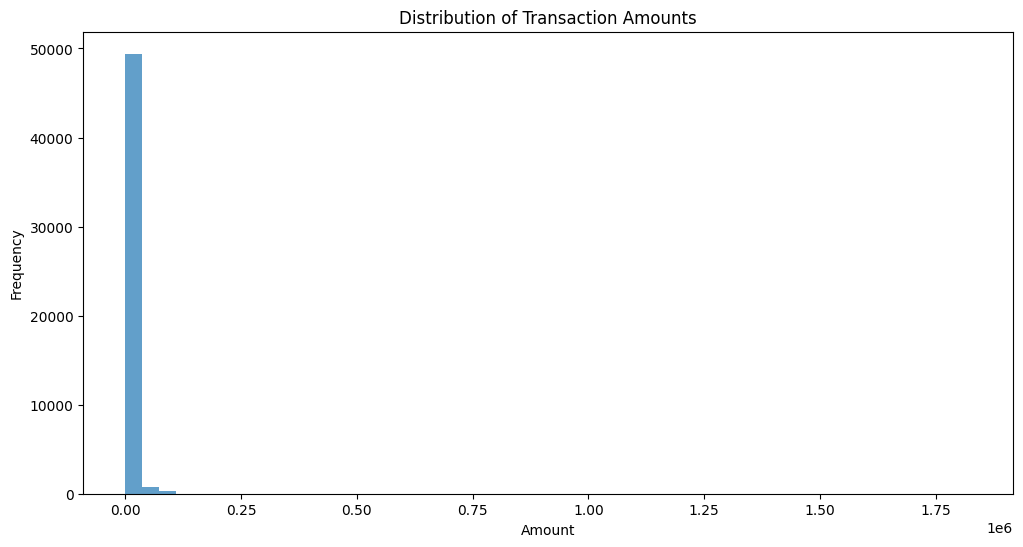

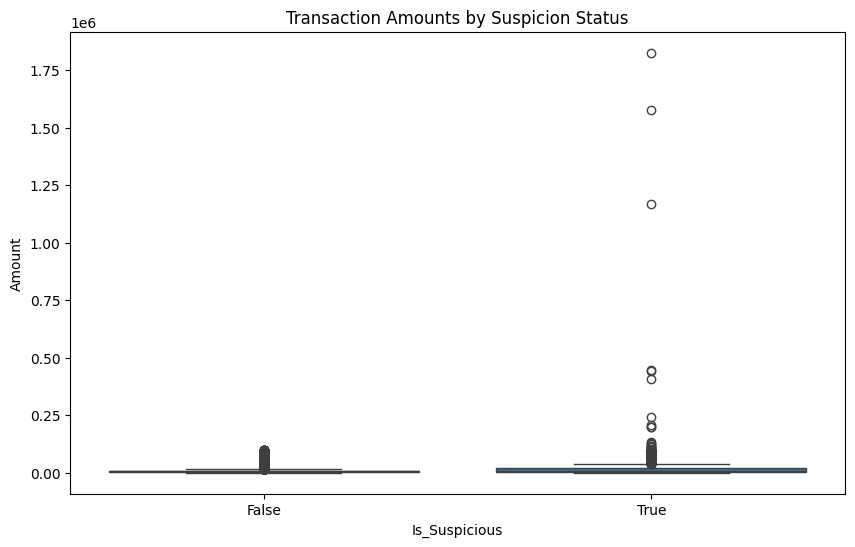

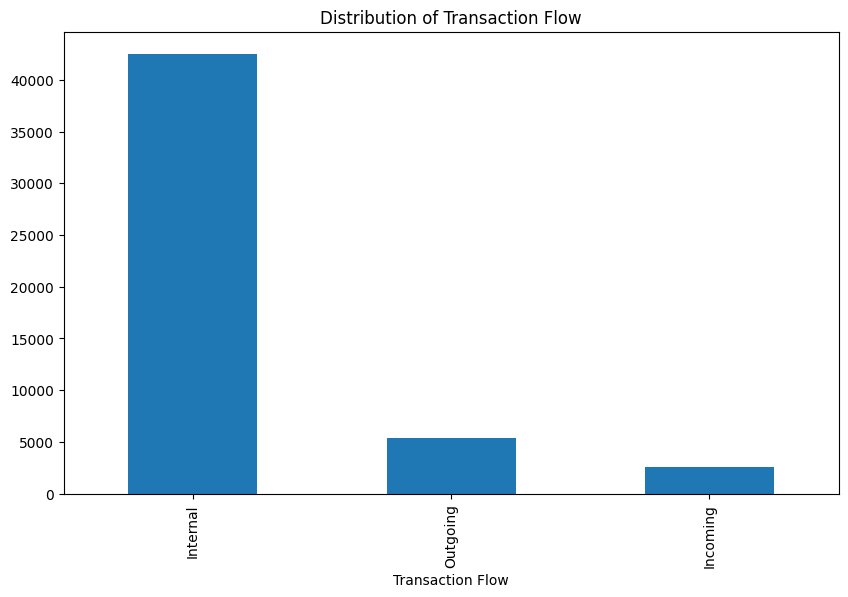

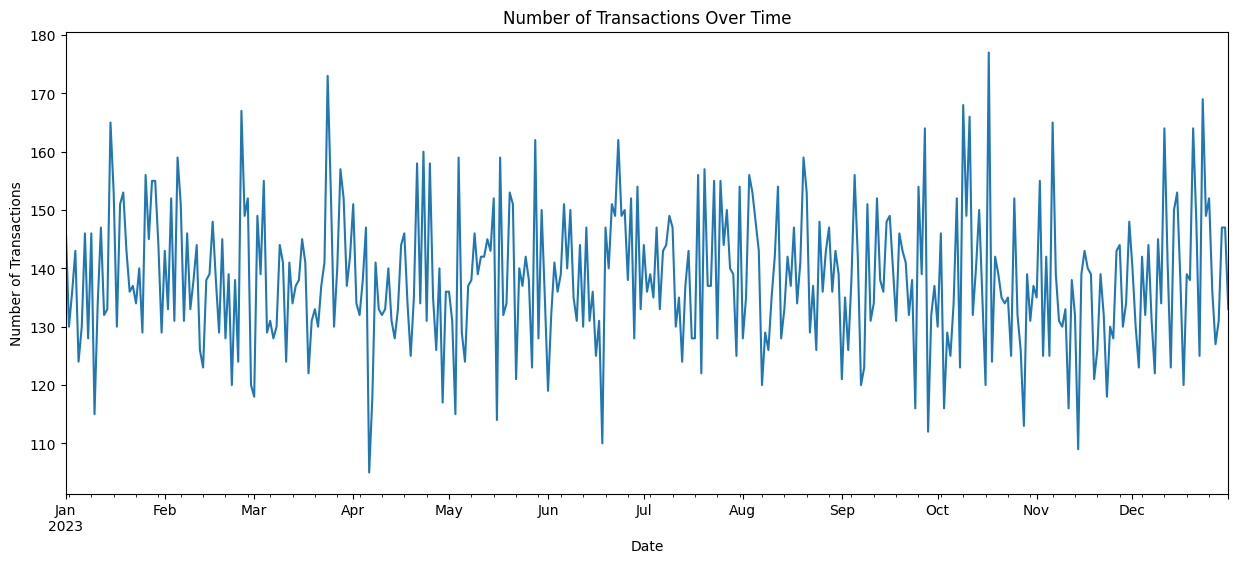


High-Risk Country Statistics:
Total transactions from high-risk countries: 1
Suspicious transactions from high-risk countries: 1

Transaction Amount Ranges:
Amount
0-10k       47887
10k-50k      1999
50k-100k      596
100k+          18
Name: count, dtype: int64

Suspicious Transactions by Amount Range:
Is_Suspicious  False  True 
Amount                     
0-10k          46147   1740
10k-50k         1597    402
50k-100k         234    362
100k+              0     18

Transaction Type by Suspicion Status:
Is_Suspicious      False  True 
Transaction Type               
Cash Deposit         964     39
Cash Withdrawal      940     25
Cash deposit           8      4
Cash withdrawal     2444    128
Currency Exchange   2430     88
SEPA                 915     47
SWIFT                665    382
WIRE               39612   1809


<Figure size 1200x600 with 0 Axes>

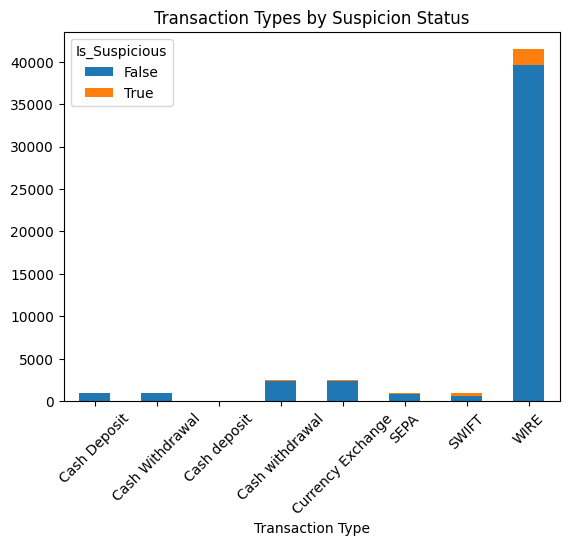


Currency Usage in Suspicious Transactions:
Is_Suspicious  False  True 
Currency                   
CHF             9604    514
EUR             9551    527
GBP             9759    508
JPY             9419    490
USD             9645    483


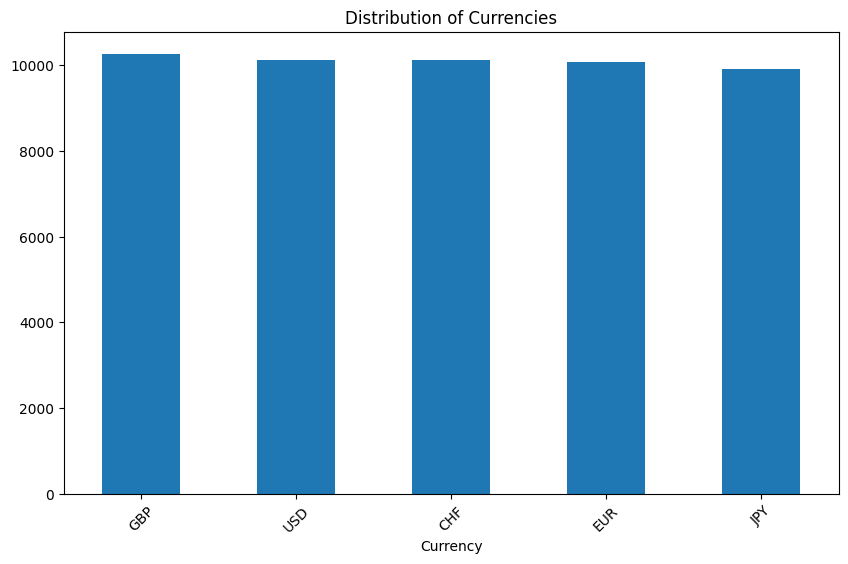

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Load the synthetic data
synthetic_data = pd.read_csv('synthetic_transactions_structured_500_5.csv')

# 1. Basic Statistics
print("Basic Statistics for Amount:")
print(synthetic_data['Amount'].describe())

# 2. Transaction Analysis
print("\nTransaction Type Distribution:")
print(synthetic_data['Transaction Type'].value_counts(normalize=True))

print("\nCurrency Distribution:")
print(synthetic_data['Currency'].value_counts(normalize=True))

print("\nTop 10 Countries:")
print(synthetic_data['Country'].value_counts().head(10))

# 3. Suspicious Transaction Analysis
suspicious_ratio = synthetic_data['Is_Suspicious'].mean()
print(f"\nSuspicious Transaction Ratio: {suspicious_ratio:.2%}")

# Average amount by suspicion status
print("\nAverage Amount by Suspicion Status:")
print(synthetic_data.groupby('Is_Suspicious')['Amount'].mean())

# Distribution of Suspicion Categories
print("\nDistribution of Suspicion Categories:")
print(synthetic_data['Suspicion Category'].value_counts(normalize=True))

# 4. Visualizations
plt.figure(figsize=(12, 6))
plt.hist(synthetic_data['Amount'], bins=50, alpha=0.7)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# Box plot of amounts by suspicion status
plt.figure(figsize=(10, 6))
sns.boxplot(x='Is_Suspicious', y='Amount', data=synthetic_data)
plt.title('Transaction Amounts by Suspicion Status')
plt.show()

# Transaction flow analysis
plt.figure(figsize=(10, 6))
synthetic_data['Transaction Flow'].value_counts().plot(kind='bar')
plt.title('Distribution of Transaction Flow')
plt.show()

# 5. Time Series Analysis
# Convert Date to datetime
synthetic_data['Date'] = pd.to_datetime(synthetic_data['Date'])

# Transaction count over time
plt.figure(figsize=(15, 6))
synthetic_data.groupby('Date').size().plot()
plt.title('Number of Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.show()

# 6. High-Risk Analysis
high_risk_countries = ['Cayman Islands', 'British Virgin Islands', 'Panama']
high_risk_transactions = synthetic_data[synthetic_data['Country'].isin(high_risk_countries)]

print("\nHigh-Risk Country Statistics:")
print(f"Total transactions from high-risk countries: {len(high_risk_transactions)}")
print(f"Suspicious transactions from high-risk countries: {len(high_risk_transactions[high_risk_transactions['Is_Suspicious']])}")

# 7. Amount Range Analysis
amount_ranges = pd.cut(synthetic_data['Amount'],
                      bins=[0, 10000, 50000, 100000, float('inf')],
                      labels=['0-10k', '10k-50k', '50k-100k', '100k+'])
print("\nTransaction Amount Ranges:")
print(amount_ranges.value_counts())

# Suspicious transactions by amount range
print("\nSuspicious Transactions by Amount Range:")
suspicious_by_range = pd.crosstab(amount_ranges, synthetic_data['Is_Suspicious'])
print(suspicious_by_range)

# 8. Transaction Type Analysis
print("\nTransaction Type by Suspicion Status:")
print(pd.crosstab(synthetic_data['Transaction Type'], synthetic_data['Is_Suspicious']))

# Visualization of suspicious transactions by transaction type
plt.figure(figsize=(12, 6))
suspicious_by_type = pd.crosstab(synthetic_data['Transaction Type'], synthetic_data['Is_Suspicious'])
suspicious_by_type.plot(kind='bar', stacked=True)
plt.title('Transaction Types by Suspicion Status')
plt.xticks(rotation=45)
plt.show()

# 9. Currency Analysis
print("\nCurrency Usage in Suspicious Transactions:")
currency_suspicious = pd.crosstab(synthetic_data['Currency'], synthetic_data['Is_Suspicious'])
print(currency_suspicious)

# Plot currency distribution
plt.figure(figsize=(10, 6))
synthetic_data['Currency'].value_counts().plot(kind='bar')
plt.title('Distribution of Currencies')
plt.xticks(rotation=45)
plt.show()

##2

### DATA QUALITY REPORT ###

1. BASIC DATA QUALITY METRICS
--------------------------------------------------
Total Records: 50500
Missing Values:
Transaction_id        0
Sender                0
Receiver              0
Amount                0
Currency              0
Country               0
Transaction Type      0
Description           0
Date                  0
Transaction Flow      0
Is_Suspicious         0
Suspicion Category    0
dtype: int64

Duplicate Records: 0

2. TRANSACTION AMOUNT ANALYSIS
--------------------------------------------------

Amount Statistics:
count    5.050000e+04
mean     6.797953e+03
std      1.564496e+04
min      5.000000e+01
25%      2.649450e+03
50%      5.140305e+03
75%      7.860675e+03
max      1.826344e+06
Name: Amount, dtype: float64


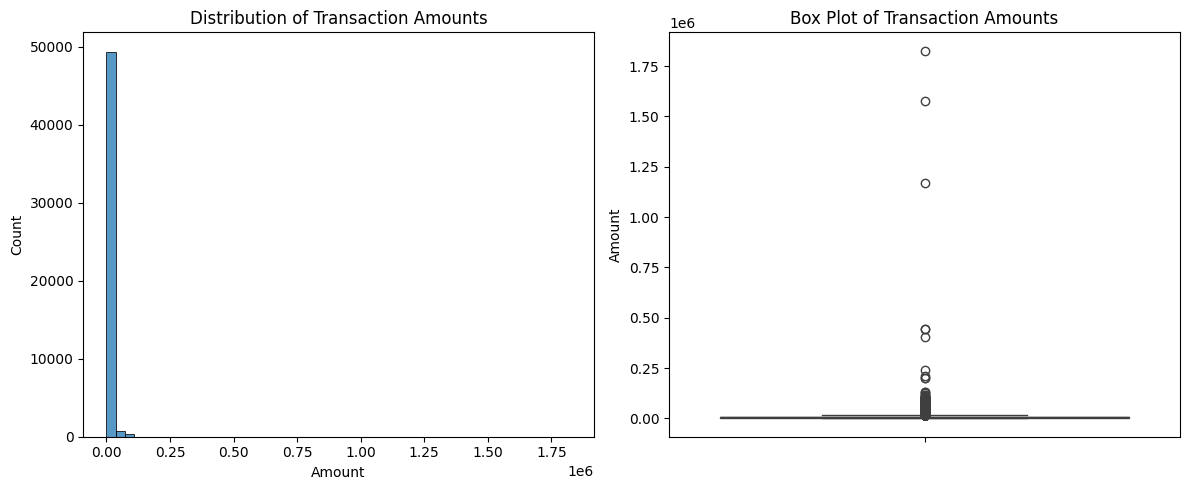


3. SUSPICIOUS TRANSACTION ANALYSIS
--------------------------------------------------
Suspicious Transaction Ratio: 4.99%

Amount Statistics by Suspicion Status:
                 count          mean           std    min        25%  \
Is_Suspicious                                                          
False          47978.0   5992.430582   6859.012580   50.0  2610.2925   
True            2522.0  22122.037803  61321.811282  100.0  3874.7000   

                    50%      75%        max  
Is_Suspicious                                
False          5042.125   7740.0    99360.0  
True           7728.925  17945.0  1826344.0  


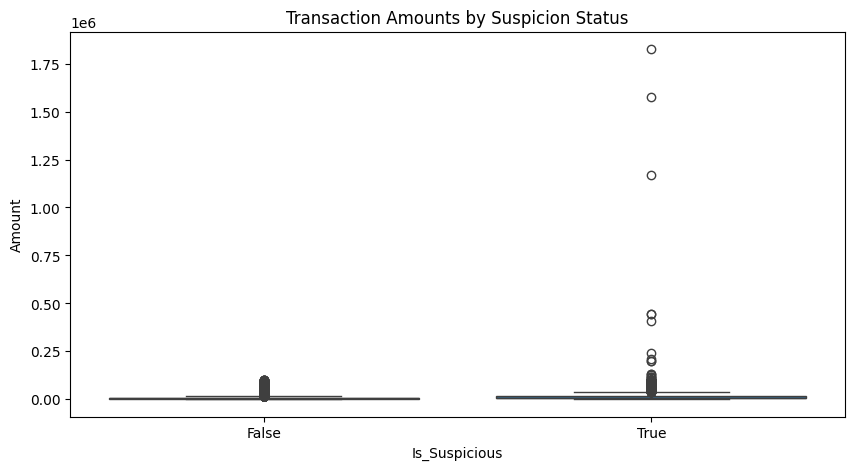


4. CATEGORICAL VARIABLE ANALYSIS
--------------------------------------------------

Currency Distribution:
Currency
GBP    0.203307
USD    0.200554
CHF    0.200356
EUR    0.199564
JPY    0.196218
Name: proportion, dtype: float64


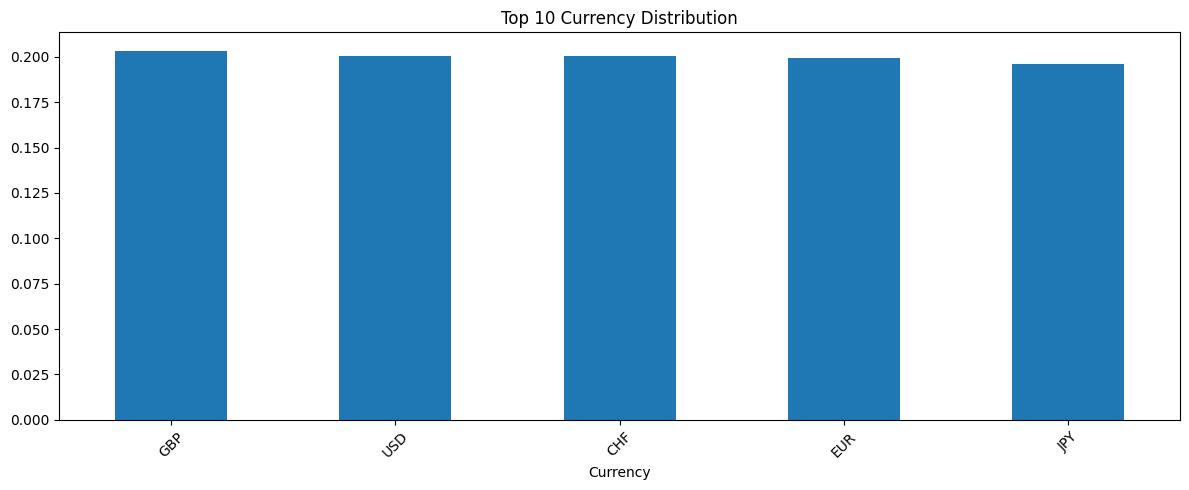


Country Distribution:
Country
Germany           0.284317
United Kingdom    0.279921
United States     0.279426
Antarctica        0.002832
New Caledonia     0.002812
Name: proportion, dtype: float64


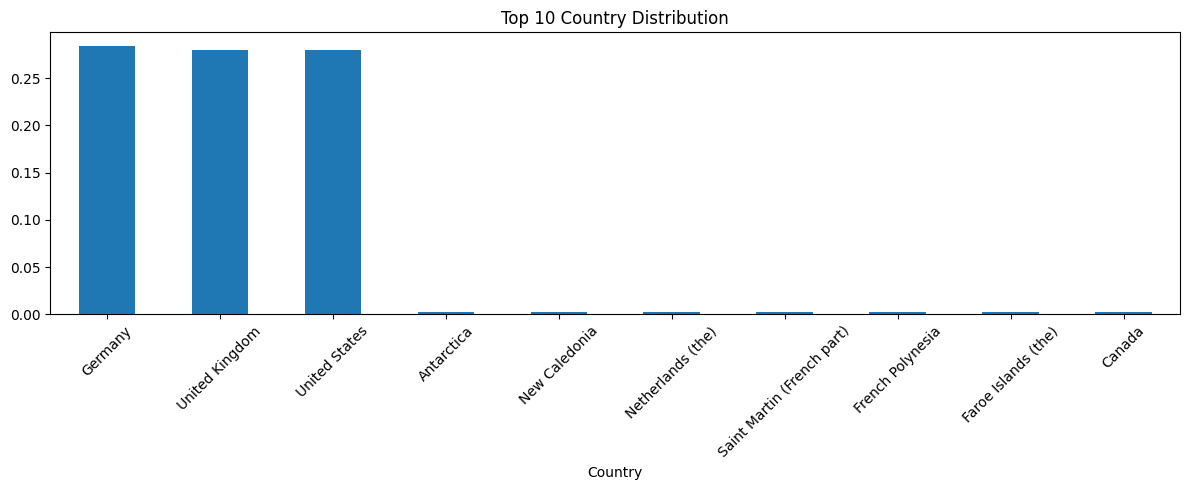


Transaction Type Distribution:
Transaction Type
WIRE                 0.820218
Cash withdrawal      0.050931
Currency Exchange    0.049861
SWIFT                0.020733
Cash Deposit         0.019861
Name: proportion, dtype: float64


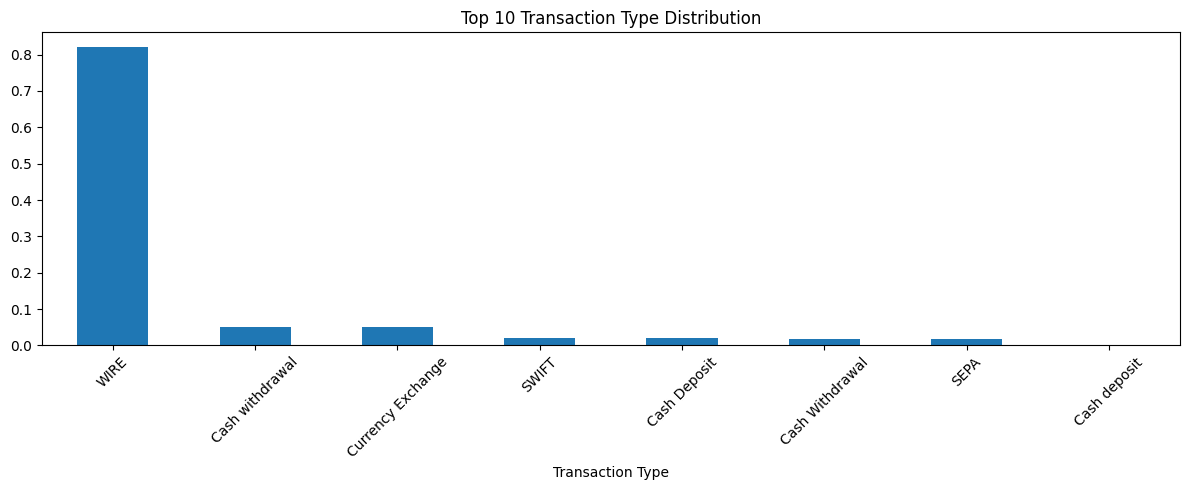


Transaction Flow Distribution:
Transaction Flow
Internal    0.841941
Outgoing    0.106277
Incoming    0.051782
Name: proportion, dtype: float64


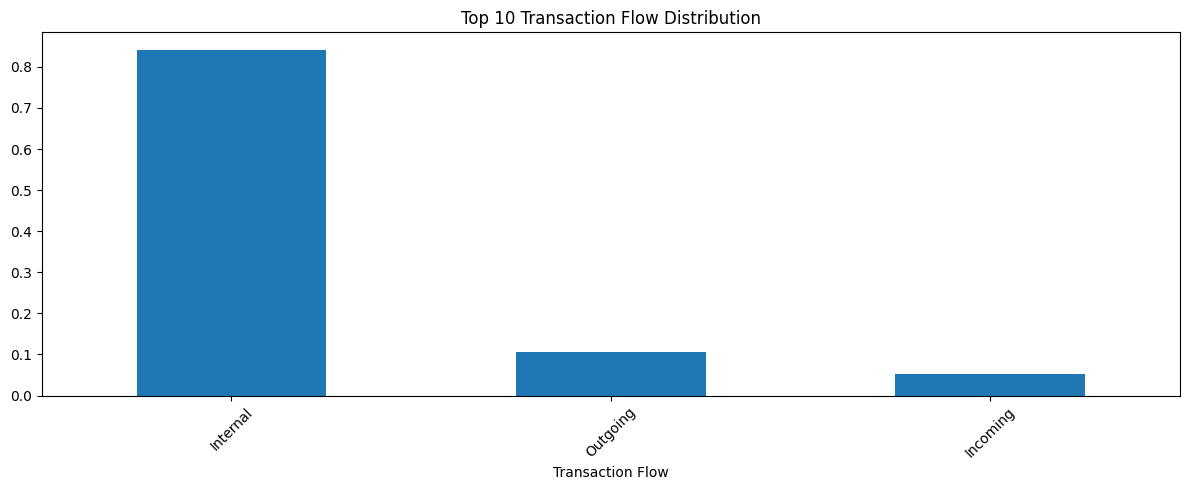


Suspicion Category Distribution:
Suspicion Category
Normal                                  0.949168
Turnover Threshold Exceeded             0.042356
Repetitive Missing Reference Numbers    0.000990
Many-to-One Pattern                     0.000990
One-to-Many Pattern                     0.000574
Name: proportion, dtype: float64


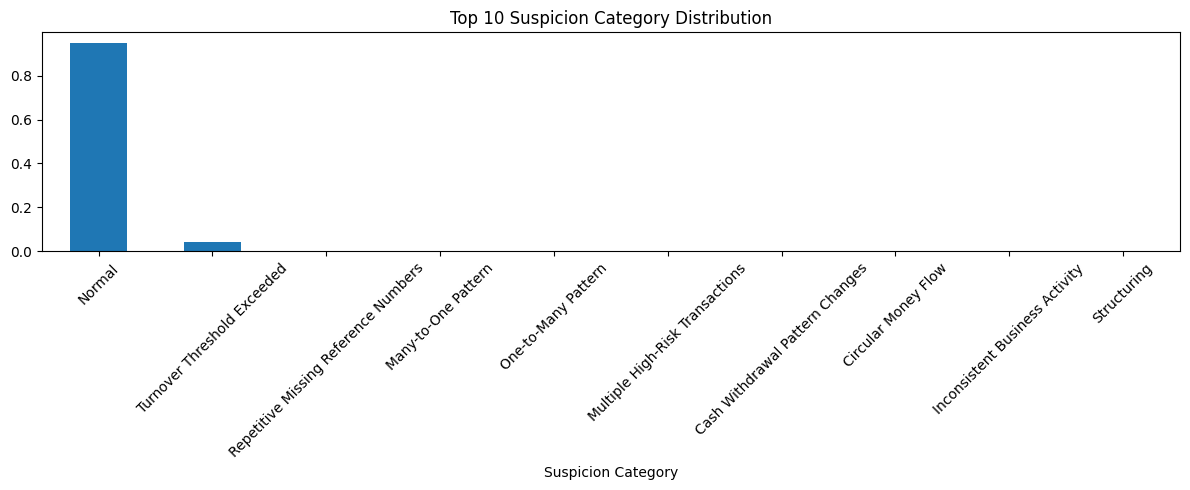


5. TEMPORAL ANALYSIS
--------------------------------------------------


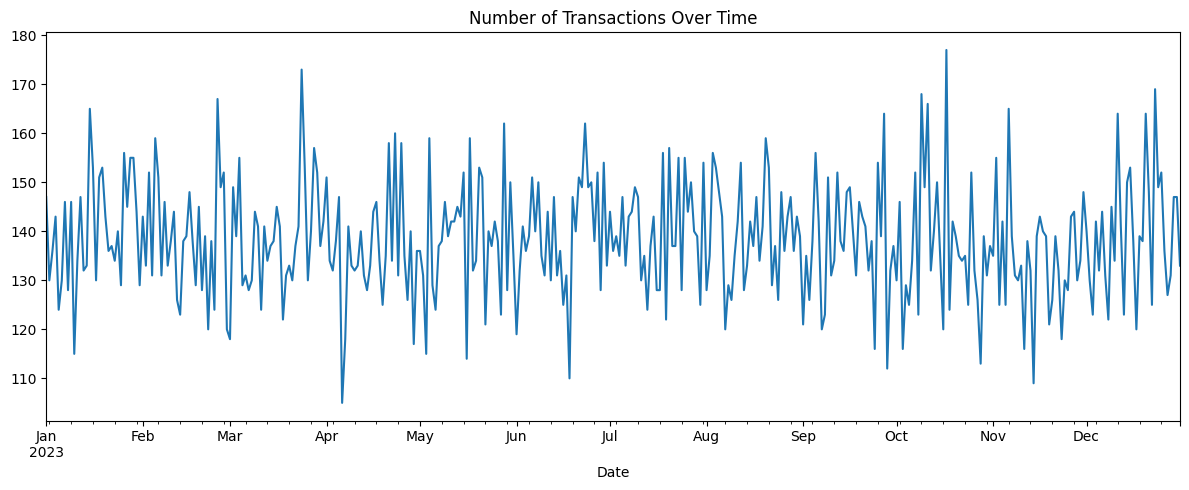


6. PATTERN ANALYSIS
--------------------------------------------------

Currency usage in suspicious transactions:
Is_Suspicious     False     True 
Currency                         
CHF            0.949199  0.050801
EUR            0.947708  0.052292
GBP            0.950521  0.049479
JPY            0.950550  0.049450
USD            0.952310  0.047690

High-risk country transactions: 1
Suspicious transactions in high-risk countries: 1

7. DATA QUALITY SCORES
--------------------------------------------------
Completeness Score: 100.00%
Uniqueness Score: 100.00%
Currency Consistency Score: 100.00%

8. RELATIONSHIP ANALYSIS
--------------------------------------------------


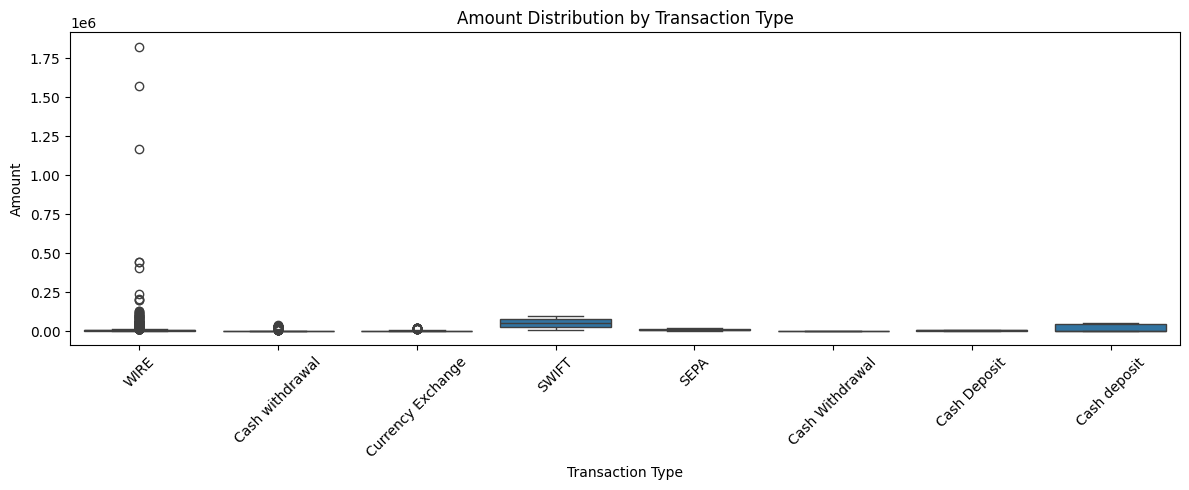


Suspicious patterns by Transaction Flow:
Is_Suspicious        False     True 
Transaction Flow                    
Incoming          0.848948  0.151052
Internal          0.966391  0.033609
Outgoing          0.869946  0.130054

9. SUMMARY AND RECOMMENDATIONS
--------------------------------------------------

Identified Issues:
No major issues identified


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def test_synthetic_data(df):
    """
    Comprehensive function to test synthetic transaction data quality
    Parameters:
    df (pandas.DataFrame): The synthetic transaction dataset
    """
    print("### DATA QUALITY REPORT ###\n")

    # 1. Basic Data Quality Checks
    print("1. BASIC DATA QUALITY METRICS")
    print("-" * 50)
    print(f"Total Records: {len(df)}")
    print(f"Missing Values:\n{df.isnull().sum()}")
    print("\nDuplicate Records:", df.duplicated().sum())

    # 2. Statistical Summary of Amount
    print("\n2. TRANSACTION AMOUNT ANALYSIS")
    print("-" * 50)
    amount_stats = df['Amount'].describe()
    print("\nAmount Statistics:")
    print(amount_stats)

    # Visualize Amount Distribution
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df['Amount'], bins=50)
    plt.title('Distribution of Transaction Amounts')
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df['Amount'])
    plt.title('Box Plot of Transaction Amounts')
    plt.tight_layout()
    plt.show()

    # 3. Suspicious Transaction Analysis
    print("\n3. SUSPICIOUS TRANSACTION ANALYSIS")
    print("-" * 50)
    suspicious_ratio = df['Is_Suspicious'].mean()
    print(f"Suspicious Transaction Ratio: {suspicious_ratio:.2%}")

    # Amount by Suspicion Status
    print("\nAmount Statistics by Suspicion Status:")
    print(df.groupby('Is_Suspicious')['Amount'].describe())

    # Visualize Amount by Suspicion Status
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Is_Suspicious', y='Amount', data=df)
    plt.title('Transaction Amounts by Suspicion Status')
    plt.show()

    # 4. Categorical Variable Analysis
    print("\n4. CATEGORICAL VARIABLE ANALYSIS")
    print("-" * 50)

    categorical_cols = ['Currency', 'Country', 'Transaction Type',
                       'Transaction Flow', 'Suspicion Category']

    for col in categorical_cols:
        print(f"\n{col} Distribution:")
        dist = df[col].value_counts(normalize=True)
        print(dist.head())

        # Visualize top 10 categories
        plt.figure(figsize=(12, 5))
        dist.head(10).plot(kind='bar')
        plt.title(f'Top 10 {col} Distribution')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # 5. Temporal Analysis
    print("\n5. TEMPORAL ANALYSIS")
    print("-" * 50)

    df['Date'] = pd.to_datetime(df['Date'])

    # Transactions by date
    daily_transactions = df.groupby('Date').size()

    plt.figure(figsize=(12, 5))
    daily_transactions.plot()
    plt.title('Number of Transactions Over Time')
    plt.tight_layout()
    plt.show()

    # 6. Pattern Analysis
    print("\n6. PATTERN ANALYSIS")
    print("-" * 50)

    # Currency usage in suspicious transactions
    currency_suspicious = pd.crosstab(df['Currency'], df['Is_Suspicious'], normalize='index')
    print("\nCurrency usage in suspicious transactions:")
    print(currency_suspicious)

    # High-risk country analysis
    high_risk_countries = ['Cayman Islands', 'British Virgin Islands', 'Panama']
    high_risk_txns = df[df['Country'].isin(high_risk_countries)]
    print(f"\nHigh-risk country transactions: {len(high_risk_txns)}")
    print(f"Suspicious transactions in high-risk countries: "
          f"{len(high_risk_txns[high_risk_txns['Is_Suspicious']])}")

    # 7. Data Quality Scores
    print("\n7. DATA QUALITY SCORES")
    print("-" * 50)

    # Completeness Score
    completeness = 1 - (df.isnull().sum().sum() / (df.shape[0] * df.shape[1]))
    print(f"Completeness Score: {completeness:.2%}")

    # Uniqueness Score (based on duplicate records)
    uniqueness = 1 - (df.duplicated().sum() / len(df))
    print(f"Uniqueness Score: {uniqueness:.2%}")

    # Consistency Score (based on valid currency codes)
    valid_currencies = ['USD', 'EUR', 'GBP', 'CHF', 'JPY']
    currency_consistency = (df['Currency'].isin(valid_currencies).sum() / len(df))
    print(f"Currency Consistency Score: {currency_consistency:.2%}")

    # 8. Relationship Analysis
    print("\n8. RELATIONSHIP ANALYSIS")
    print("-" * 50)

    # Amount vs Transaction Type
    plt.figure(figsize=(12, 5))
    sns.boxplot(x='Transaction Type', y='Amount', data=df)
    plt.xticks(rotation=45)
    plt.title('Amount Distribution by Transaction Type')
    plt.tight_layout()
    plt.show()

    # Suspicious patterns by Transaction Flow
    flow_suspicious = pd.crosstab(df['Transaction Flow'], df['Is_Suspicious'], normalize='index')
    print("\nSuspicious patterns by Transaction Flow:")
    print(flow_suspicious)

    # 9. Summary and Recommendations
    print("\n9. SUMMARY AND RECOMMENDATIONS")
    print("-" * 50)

    # Data quality issues
    issues = []

    if suspicious_ratio > 0.1:
        issues.append("High suspicious transaction ratio (>10%)")

    if completeness < 0.95:
        issues.append("Low completeness score (<95%)")

    if uniqueness < 0.95:
        issues.append("Low uniqueness score (<95%)")

    if currency_consistency < 0.95:
        issues.append("Low currency consistency score (<95%)")

    if len(df['Transaction Type'].unique()) < 3:
        issues.append("Limited variety in transaction types (<3 types)")

    print("\nIdentified Issues:")
    if issues:
        for issue in issues:
            print(f"- {issue}")
    else:
        print("No major issues identified")

# Load and test the data
df = pd.read_csv('synthetic_transactions_structured_500_5.csv')
test_synthetic_data(df)